In [1]:
%matplotlib inline

# import cosima_cookbook as cc
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
# import cmocean.cm as cmocean
import glob
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.path as mpath
import matplotlib.colors as col
from netCDF4 import Dataset
import cmocean as cmo


import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

figdir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/'

In [2]:
import intake
from access_nri_intake.source.builders import AccessOm2Builder


In [3]:
client = Client(threads_per_worker=1)
client.dashboard_link

'/proxy/8787/status'

### updating with intake catalog:

In [4]:
# add experiments to my own intake:

# - control:
path_ctrl = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath"

# - basal No Gade: GPC029 (Basal)   
path_noBG = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb'

# - basal Gade Brine: GPC062 (Basal_LH_Brine)    
path_BGB = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine'
# path_BGB = '/scratch/e14/fbd581/access-om2/fbd581/access-om2/archive/01deg_jra55_ryf9091_21mbath_basal'

### SOFIA meltwater perturbation expts:
# - control:
path_ctrl_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_sofia_ssp126"

path_ctrl_antwater = "/scratch/e14/fbd581/access-om2/fbd581/access-om2/archive/01deg_jra55_ryf9091_21mbath_sofia_antwater-d0ea3a2d"

# - basal No Gade: GPC029 (Basal)   
path_noBG_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126"

# - basal Gade Brine: GPC062 (Basal_LH_Brine)    
path_BGB_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126"

path_BGB_antwater = "/scratch/e14/fbd581/access-om2/fbd581/access-om2/archive/01deg_jra55_ryf9091_21mbath_basal_sofia_antwater_SSSrestoring-c1fb6bf0"
path_testSSS = "/scratch/e14/fbd581/access-om2/fbd581/access-om2/archive/01deg_jra55_ryf9091_21mbath_testSSSrestoring-adab07c6"

# new control runs with Gadel line:
path_ctrl_BG = "/scratch/e14/fbd581/access-om2/fbd581/access-om2/archive/01deg_jra55_ryf9091_21mbath_Gade-914fd6e4"
path_ctrl_BG_antwater = "/scratch/e14/fbd581/access-om2/fbd581/access-om2/archive/01deg_jra55_ryf9091_21mbath_Gade_sofia_antwater-383eae28"
path_ctrl_antwater_BG = "/scratch/e14/fbd581/access-om2/fbd581/access-om2/archive/01deg_jra55_ryf9091_21mbath_sofia_antwater_Gade-160c9273"


#### building datastore for each experiment:

In [ ]:
%%time

builder = AccessOm2Builder(
    path=path_ctrl
).build()

builder.save(
    name="DSW_control", 
    description="Datastore for ACCESS-OM2 ryf9091 DSW control",
)

In [ ]:
%%time

builder = AccessOm2Builder(
    path=path_noBG
).build()

builder.save(
    name="Basal", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal",
)

In [ ]:
%%time

builder = AccessOm2Builder(
    path=path_BGB,
    exclude_patterns ='2delete_output041'
).build()

builder.save(
    name="Basal_LH_Brine", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal_LH_Brine",
)

In [ ]:
%%time

builder = AccessOm2Builder(
    path=path_ctrl_sofia
).build()

builder.save(
    name="DSW_control_sofia", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA control (mbath21)",
)

In [ ]:
%%time

builder = AccessOm2Builder(
    path=path_noBG_sofia
).build()

builder.save(
    name="Basal_sofia", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA Basal rep.",
)

In [ ]:
%%time

builder = AccessOm2Builder(
    path=path_BGB_sofia
).build()

builder.save(
    name="Basal_LH_Brine_sofia", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA Basal_LH_Brine rep.",
)

In [ ]:
%%time

builder = AccessOm2Builder(
    path=path_ctrl_antwater
).build()

builder.save(
    name="DSW_control_antwater", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA Antwater control (mbath21)",
)

In [ ]:
%%time

builder = AccessOm2Builder(
    path=path_BGB_antwater
).build()

builder.save(
    name="Basal_LH_Brine_antwater", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA Antwater Basal_LH_Brine",
)

In [ ]:
# %%time

# builder = AccessOm2Builder(
#     path=path_testSSS
# ).build()

# builder.save(
#     name="DSW_control_noSSSrest", 
#     description="Datastore for ACCESS-OM2 ryf9091 control without SSS restoring",
# )

In [ ]:
%%time

builder = AccessOm2Builder(
    path=path_ctrl_BG
).build()

builder.save(
    name="DSW_control_LH", 
    description="Datastore for ACCESS-OM2 ryf9091 control + Antwater applying Gade line (all runoff)",
)

In [ ]:
%%time

builder = AccessOm2Builder(
    path=path_ctrl_antwater_BG
).build()

builder.save(
    name="DSW_control_antwater_LH", 
    description="Datastore for ACCESS-OM2 ryf9091 control applying Gade line only for Antwater anomaly",
)

In [ ]:
%%time

builder = AccessOm2Builder(
    path=path_ctrl_BG_antwater
).build()

builder.save(
    name="DSW_control_LH_antwater", 
    description="Datastore for ACCESS-OM2 ryf9091 control applying Gade line only for Antwater anomaly",
)

#### loading intake datastore for individual experiments:

In [5]:
cat = intake.open_esm_datastore(
    "./DSW_control.json",
    columns_with_iterables=["variable"] 
)
# ds = cat.search(variable="temp").to_dask()

cat_noBG = intake.open_esm_datastore(
    "./Basal_noGade.json",
    columns_with_iterables=["variable"] 
)

# cat_BG = intake.open_esm_datastore(
#     "./Basal_LH.json",
#     columns_with_iterables=["variable"] 
# )

cat_BGB = intake.open_esm_datastore(
    "./Basal_LH_Brine.json",
    columns_with_iterables=["variable"] 
)

cat_sofia = intake.open_esm_datastore(
    "./DSW_control_sofia.json",
    columns_with_iterables=["variable"] 
)

cat_noBG_sofia = intake.open_esm_datastore(
    "./Basal_sofia.json",
    columns_with_iterables=["variable"] 
)

cat_BGB_sofia = intake.open_esm_datastore(
    "./Basal_LH_Brine_sofia.json",
    columns_with_iterables=["variable"] 
)

cat_antwater = intake.open_esm_datastore(
    "./DSW_control_antwater.json",
    columns_with_iterables=["variable"] 
)

cat_BGB_antwater = intake.open_esm_datastore(
    "./Basal_LH_Brine_antwater.json",
    columns_with_iterables=["variable"] 
)

cat_SSStest = intake.open_esm_datastore(
    "./DSW_control_noSSSrest.json",
    columns_with_iterables=["variable"] 
)

cat_ctrlBG = intake.open_esm_datastore(
    "./DSW_control_LH.json",
    columns_with_iterables=["variable"] 
)

cat_ctrlBG_antwater = intake.open_esm_datastore(
    "./DSW_control_LH_antwater.json",
    columns_with_iterables=["variable"] 
)

cat_ctrl_antwater_BG = intake.open_esm_datastore(
    "./DSW_control_antwater_LH.json",
    columns_with_iterables=["variable"] 
)

#### load area and layer thickness:

In [6]:
%%time
# Make sure these match the available restarts:
start_time='1917-01-01'
end_time='1919-12-31'
# start_time='1900-01-01'
# end_time='1901-12-31'

lat_slice  = slice(-80,-59)



## example:
#  d1 = cat.search(variable="pme_net", frequency='1mon').to_dask()
#  pme_net_ctrl = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

CPU times: user 7 μs, sys: 22 μs, total: 29 μs
Wall time: 57.2 μs


In [7]:
## load area and ht (for plotting):
d1 = cat.search(variable="area_t",path='/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output000/ocean/ocean_grid.nc').to_dask()
oc_grd = d1.sel(yt_ocean=lat_slice)
area_t = oc_grd.area_t

d2 = cat.search(variable="ht",path='/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output000/ocean/ocean_grid.nc').to_dask()
oc_grd = d2.isel(yt_ocean=lat_slice)
ht = oc_grd.ht

land_mask = np.squeeze(ht)*0
land_mask_fld = land_mask.fillna(1)
land_mask_fld = np.where(land_mask_fld==1,land_mask_fld,np.nan)
land_mask_masked = np.ma.masked_where((land_mask_fld==0),land_mask_fld)

# make land go all the way to -90S:
land_mask_lat = ht.yt_ocean.values
land_mask_lat[0] = -90

fontsize=15

#### load temp/salt, runoff, basal_fwflx2d, SSS restoring fluxes

In [8]:
## plot temperature all experiments:

t1 = cat.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)
t2 = cat_noBG.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)
t3 = cat_BGB.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)

t1s = cat_sofia.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)
t2s = cat_noBG_sofia.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)
t3s = cat_BGB_sofia.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)

# t1ts = cat_SSStest.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)

t1a = cat_antwater.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)
t3a = cat_BGB_antwater.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)


In [9]:
t1b = cat_ctrlBG.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)
t1a_b = cat_ctrlBG_antwater.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)
t1a_c = cat_ctrl_antwater_BG.search(variable="temp",frequency='1mon').to_dask(decode_timedelta=True)


In [10]:
## plot salinity all experiments:

s1 = cat.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)
s2 = cat_noBG.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)
s3 = cat_BGB.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)
s1s = cat_sofia.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)
s2s = cat_noBG_sofia.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)
s3s = cat_BGB_sofia.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)

# s1ts = cat_SSStest.search(variable="salt",frequency='1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True,'chunks' :{'time' : 2}})

s1a = cat_antwater.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)
s3a = cat_BGB_antwater.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)


In [11]:
s1b = cat_ctrlBG.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)
s1a_b = cat_ctrlBG_antwater.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)
s1a_c = cat_ctrl_antwater_BG.search(variable="salt",frequency='1mon').to_dask(decode_timedelta=True)


In [12]:
d1 = cat.search(variable="runoff",frequency='1mon').to_dask(decode_timedelta=True)
d2 = cat_noBG.search(variable="runoff",frequency='1mon').to_dask(decode_timedelta=True)
d3 = cat_BGB.search(variable="runoff",frequency='1mon').to_dask(decode_timedelta=True)

d1s = cat_sofia.search(variable="runoff",frequency='1mon').to_dask(decode_timedelta=True)
d2s = cat_noBG_sofia.search(variable="runoff",frequency='1mon').to_dask(decode_timedelta=True)
d3s = cat_BGB_sofia.search(variable="runoff",frequency='1mon').to_dask(decode_timedelta=True)

# d1ts = cat_SSStest.search(variable="runoff",frequency='1mon').to_dask(decode_timedelta=True)

d1a = cat_antwater.search(variable="runoff",frequency='1mon').to_dask(decode_timedelta=True)
d3a = cat_BGB_antwater.search(variable="runoff",frequency='1mon').to_dask(decode_timedelta=True)

d1b = cat_ctrlBG.search(variable="runoff",frequency='1mon').to_dask(decode_timedelta=True)
d1a_b = cat_ctrlBG_antwater.search(variable="runoff",frequency='1mon').to_dask(decode_timedelta=True)
d1a_c = cat_ctrl_antwater_BG.search(variable="runoff",frequency='1mon').to_dask(decode_timedelta=True)


In [13]:
# Basal and Basal_LH_Brine needs to accoutn for "basal_fwflx2d" in the runoff term:
# d6 = cat_BGB.search(variable="basal_fwflx2d", frequency='1mon').to_dask()
# basal2d_BGB = d6.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d2b = cat_noBG.search(variable="basal_fwflx2d",frequency='1mon',file_id='ocean_monthly_2d_basal').to_dask(decode_timedelta=True)
d3b = cat_BGB.search(variable="basal_fwflx2d",frequency='1mon',file_id='ocean.1mon.nv:2.xt_ocean:3600.yt_ocean:2700').to_dask(decode_timedelta=True)
# d2b_s = cat_noBG_sofia.search(variable="basal_fwflx2d",frequency='1mon',file_id='ocean_monthly_2d_basal').to_dask(decode_timedelta=True)
d3b_s = cat_BGB_sofia.search(variable="basal_fwflx2d",frequency='1mon').to_dask(decode_timedelta=True)

d3b_s = cat_BGB_antwater.search(variable="basal_fwflx2d",frequency='1mon').to_dask(decode_timedelta=True)
d1b_a_b = cat_ctrlBG_antwater.search(variable="basal_fwflx2d",frequency='1mon').to_dask(decode_timedelta=True)
d1b_a_c = cat_ctrl_antwater_BG.search(variable="basal_fwflx2d",frequency='1mon').to_dask(decode_timedelta=True)


In [14]:
sr1 = cat.search(variable="sfc_salt_flux_restore",frequency='1mon').to_dask(decode_timedelta=True)
sr2 = cat_noBG.search(variable="sfc_salt_flux_restore",frequency='1mon').to_dask(decode_timedelta=True)
sr3 = cat_BGB.search(variable="sfc_salt_flux_restore",frequency='1mon').to_dask(decode_timedelta=True)
sr1s = cat_sofia.search(variable="sfc_salt_flux_restore",frequency='1mon').to_dask(decode_timedelta=True)
sr2s = cat_noBG_sofia.search(variable="sfc_salt_flux_restore",frequency='1mon').to_dask(decode_timedelta=True)
sr3s = cat_BGB_sofia.search(variable="sfc_salt_flux_restore",frequency='1mon').to_dask(decode_timedelta=True)

sr1st = cat.search(variable="sfc_salt_flux_restore",frequency='1mon').to_dask(decode_timedelta=True)

sr1a = cat_antwater.search(variable="sfc_salt_flux_restore",frequency='1mon').to_dask(decode_timedelta=True)
sr3a = cat_BGB_antwater.search(variable="sfc_salt_flux_restore",frequency='1mon').to_dask(decode_timedelta=True)


### 1st check on the results - maps of SST/SSS (monthly/annual)
Check plot temperature difference (maps) between sofia x ctrl experiments:
- there's lots of differences growing from the high energetic regions (WBCs, ACC), but at the Antarctica shelf there's only the near coastline anomalies as expected

#### control: SST partI vs SOFIA

In [19]:
t1.st_ocean

<xarray.DataArray 'st_ocean' (st_ocean: 75)> Size: 600B
array([5.412808e-01, 1.680735e+00, 2.939953e+00, 4.331521e+00, 5.869350e+00,
       7.568810e+00, 9.446885e+00, 1.152234e+01, 1.381593e+01, 1.635055e+01,
       1.915154e+01, 2.224687e+01, 2.566746e+01, 2.944746e+01, 3.362460e+01,
       3.824057e+01, 4.334140e+01, 4.897796e+01, 5.520640e+01, 6.208874e+01,
       6.969342e+01, 7.809601e+01, 8.737988e+01, 9.763700e+01, 1.089687e+02,
       1.214869e+02, 1.353144e+02, 1.505868e+02, 1.674530e+02, 1.860765e+02,
       2.066365e+02, 2.293296e+02, 2.543701e+02, 2.819920e+02, 3.124492e+02,
       3.460166e+02, 3.829906e+02, 4.236883e+02, 4.684475e+02, 5.176242e+02,
       5.715899e+02, 6.307275e+02, 6.954248e+02, 7.660668e+02, 8.430255e+02,
       9.266482e+02, 1.017244e+03, 1.115068e+03, 1.220309e+03, 1.333076e+03,
       1.453384e+03, 1.581154e+03, 1.716205e+03, 1.858264e+03, 2.006975e+03,
       2.161913e+03, 2.322601e+03, 2.488533e+03, 2.659189e+03, 2.834054e+03,
       3.012631e+03, 3.194453e+03, 3.379089e+03, 3.566145e+03, 3.755274e+03,
       3.946166e+03, 4.138551e+03, 4.332197e+03, 4.526903e+03, 4.722497e+03,
       4.918835e+03, 5.115794e+03, 5.313270e+03, 5.511177e+03, 5.709443e+03])
Coordinates:
  * st_ocean  (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
Attributes:
    long_name:       tcell zstar depth
    units:           meters
    cartesian_axis:  Z
    positive:        down
    edges:           st_edges_ocean

/g/data/e14/fbd581/basal_mom5-collaborative-project/SST_anoml_control_antwater_LH.png


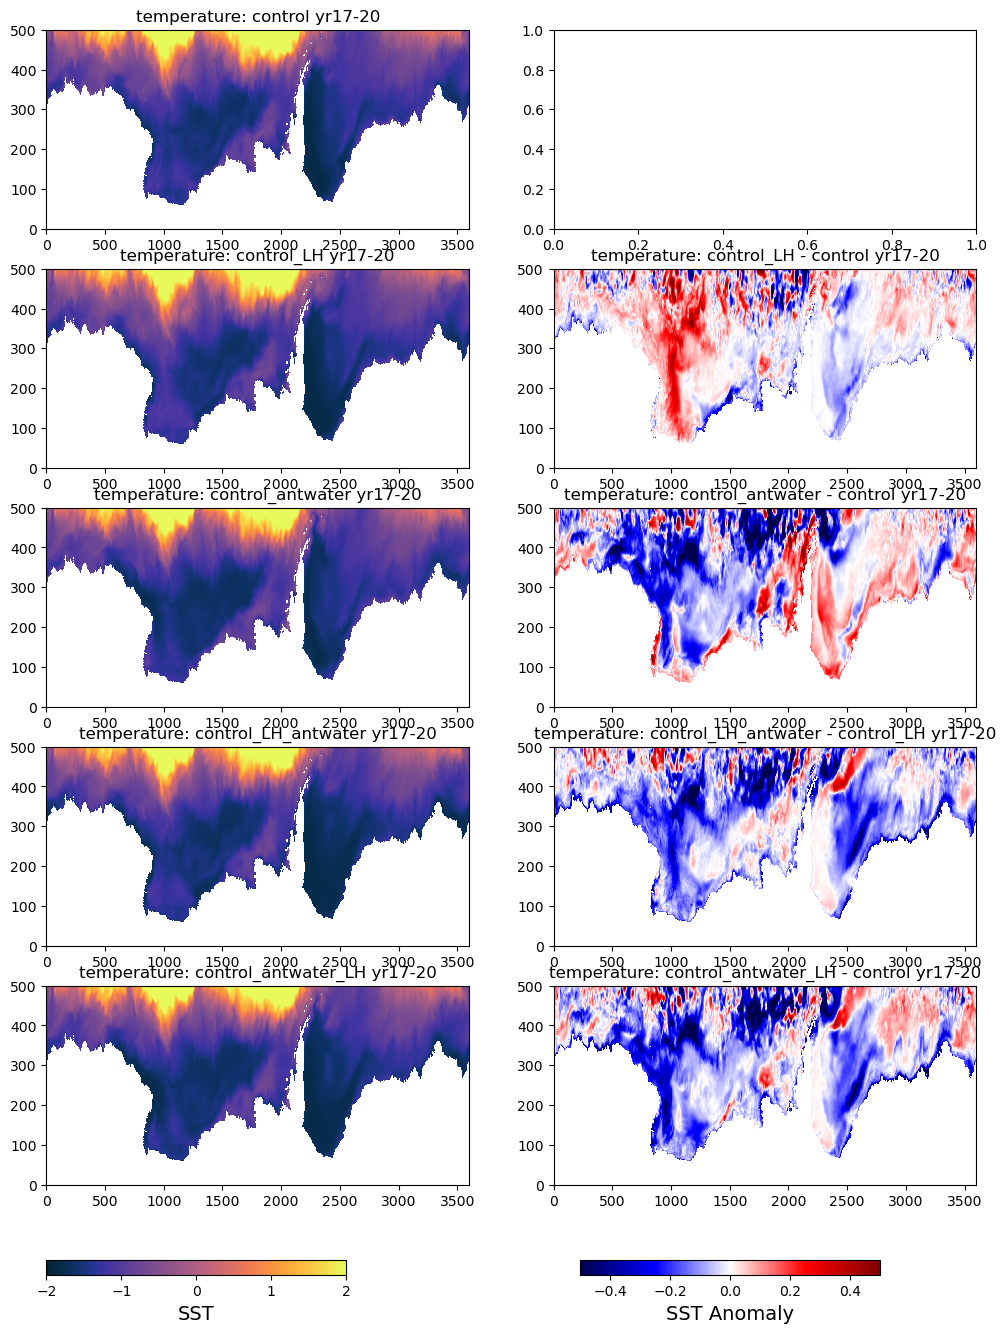

In [20]:
## SST

fig, ax  = plt.subplots(nrows=5, ncols=2, figsize = (12,15))
ct=ax[0,0].pcolormesh(t1.isel(time=slice(204,240),st_ocean=0).mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[0,0].set_title('temperature: control yr17-20')
ax[0,0].set_ylim(0,500)
ax[1,0].pcolormesh(t1b.isel(time=slice(201,237),st_ocean=0).mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[1,0].set_title('temperature: control_LH yr17-20')
ax[1,0].set_ylim(0,500)
ax[2,0].pcolormesh(t1a.isel(time=slice(87,123),st_ocean=0).mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[2,0].set_title('temperature: control_antwater yr17-20')
ax[2,0].set_ylim(0,500)
ax[3,0].pcolormesh(t1a_b.isel(time=slice(84,120),st_ocean=0).mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[3,0].set_title('temperature: control_LH_antwater yr17-20')
ax[3,0].set_ylim(0,500)
ax[4,0].pcolormesh(t1a_c.isel(time=slice(84,120),st_ocean=0).mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[4,0].set_title('temperature: control_antwater_LH yr17-20')
ax[4,0].set_ylim(0,500)

cta=ax[1,1].pcolormesh(t1b.isel(time=slice(201,237),st_ocean=0).mean('time').temp-
                   t1.isel(time=slice(204,240),st_ocean=0).mean('time').temp,vmin=-.5,vmax=.5, cmap='seismic')
ax[1,1].set_title('temperature: control_LH - control yr17-20')
ax[1,1].set_ylim(0,500)

cta=ax[2,1].pcolormesh(t1a.isel(time=slice(87,123),st_ocean=0).mean('time').temp-
                   t1.isel(time=slice(204,240),st_ocean=0).mean('time').temp,vmin=-.5,vmax=.5, cmap='seismic')
ax[2,1].set_title('temperature: control_antwater - control yr17-20')
ax[2,1].set_ylim(0,500)

ax[3,1].pcolormesh(t1a_b.isel(time=slice(84,120),st_ocean=0).mean('time').temp-
                   t1b.isel(time=slice(201,237),st_ocean=0).mean('time').temp,vmin=-.5,vmax=.5, cmap='seismic')
ax[3,1].set_title('temperature: control_LH_antwater - control_LH yr17-20')
ax[3,1].set_ylim(0,500)

ax[4,1].pcolormesh(t1a_c.isel(time=slice(84,120),st_ocean=0).mean('time').temp-
                   t1.isel(time=slice(204,240),st_ocean=0).mean('time').temp,vmin=-.5,vmax=.5, cmap='seismic')
ax[4,1].set_title('temperature: control_antwater_LH - control yr17-20')
ax[4,1].set_ylim(0,500)

cax1 = fig.add_axes([0.125, 0.05, 0.25, 0.01])
cbar1=plt.colorbar(ct, cax=cax1, orientation='horizontal')#, shrink = 0.5, ticks = [0, 0.5, 1, 1.5, 2, 2.5, 3])
cbar1.set_label(r'SST', fontsize = 14)


cax2 = fig.add_axes([0.57, 0.05, 0.25, 0.01])
cbar2=plt.colorbar(cta, cax=cax2, orientation='horizontal')#, shrink = 0.5, ticks = [0, 0.5, 1, 1.5, 2, 2.5, 3])
cbar2.set_label(r'SST Anomaly', fontsize = 14)
plt.savefig(figdir+'SST_anoml_control_antwater_LH.png',bbox_inches='tight',dpi=300)
print(figdir+'SST_anoml_control_antwater_LH.png')

In [ ]:
# SSS

fig, ax  = plt.subplots(nrows=5, ncols=2, figsize = (12,15))
ct=ax[0,0].pcolormesh(s1.isel(time=slice(204,240),st_ocean=0).mean('time').salt,vmin=32,vmax=34.95, cmap=cmo.cm.haline)
ax[0,0].set_title('salinity: control yr17-20')
ax[0,0].set_ylim(0,500)
ax[1,0].pcolormesh(s1b.isel(time=slice(201,237),st_ocean=0).mean('time').salt,vmin=32,vmax=34.95, cmap=cmo.cm.haline)
ax[1,0].set_title('salinity: control_LH yr17-20')
ax[1,0].set_ylim(0,500)
ax[2,0].pcolormesh(s1a.isel(time=slice(87,123),st_ocean=0).mean('time').salt,vmin=32,vmax=34.95, cmap=cmo.cm.haline)
ax[2,0].set_title('salinity: control_antwater yr17-20')
ax[2,0].set_ylim(0,500)
ax[3,0].pcolormesh(s1a_b.isel(time=slice(84,120),st_ocean=0).mean('time').salt,vmin=32,vmax=34.95, cmap=cmo.cm.haline)
ax[3,0].set_title('salinity: control_LH_antwater yr17-20')
ax[3,0].set_ylim(0,500)
ax[4,0].pcolormesh(s1a_c.isel(time=slice(84,120),st_ocean=0).mean('time').salt,vmin=32,vmax=34.95, cmap=cmo.cm.haline)
ax[4,0].set_title('salinity: control_antwater_LH yr17-20')
ax[4,0].set_ylim(0,500)

cta=ax[1,1].pcolormesh(s1b.isel(time=slice(84,120),st_ocean=0).mean('time').salt-
                   s1.isel(time=slice(204,240),st_ocean=0).mean('time').salt,vmin=-.5,vmax=.5, cmap='seismic')
ax[1,1].set_title('salinity: control_LH - control yr17-20')
ax[1,1].set_ylim(0,500)

cta=ax[2,1].pcolormesh(s1a.isel(time=slice(87,123),st_ocean=0).mean('time').salt-
                   s1.isel(time=slice(204,240),st_ocean=0).mean('time').salt,vmin=-1.5,vmax=1.5, cmap='seismic')
ax[2,1].set_title('salinity: control_antwater - control yr17-20')
ax[2,1].set_ylim(0,500)

ax[3,1].pcolormesh(s1a_b.isel(time=slice(84,120),st_ocean=0).mean('time').salt-
                   s1b.isel(time=slice(201,237),st_ocean=0).mean('time').salt,vmin=-1.5,vmax=1.5, cmap='seismic')
ax[3,1].set_title('salinity: control_LH_antwater - control_LH yr17-20')
ax[3,1].set_ylim(0,500)

ax[4,1].pcolormesh(s1a_c.isel(time=slice(84,120),st_ocean=0).mean('time').salt-
                   s1.isel(time=slice(204,240),st_ocean=0).mean('time').salt,vmin=-1.5,vmax=1.5, cmap='seismic')
ax[4,1].set_title('salinity: control_antwater_LH - control yr17-20')
ax[4,1].set_ylim(0,500)

cax1 = fig.add_axes([0.125, 0.05, 0.25, 0.01])
cbar1=plt.colorbar(ct, cax=cax1, orientation='horizontal')#, shrink = 0.5, ticks = [0, 0.5, 1, 1.5, 2, 2.5, 3])
cbar1.set_label(r'SSS', fontsize = 14)


cax2 = fig.add_axes([0.57, 0.05, 0.25, 0.01])
cbar2=plt.colorbar(cta, cax=cax2, orientation='horizontal')#, shrink = 0.5, ticks = [0, 0.5, 1, 1.5, 2, 2.5, 3])
cbar2.set_label(r'SSS Anomaly', fontsize = 14)

plt.savefig(figdir+'SSS_anoml_control_antwater_LH.png',bbox_inches='tight',dpi=300)


In [ ]:
## Runoff

# fig, ax  = plt.subplots(nrows=3, ncols=2, figsize = (12,10))

# ct=ax[0,0].pcolormesh(d1.isel(time=slice(120,128)).mean('time').runoff,vmin=0,vmax=0.0005, cmap=cmo.cm.haline)
# ax[0,0].set_title('runoff: control yr17-20')
# ax[0,0].set_ylim(0,500)
# ax[1,0].pcolormesh(d1a.isel(time=slice(3,11)).mean('time').runoff,vmin=0,vmax=0.0005, cmap=cmo.cm.haline)
# ax[1,0].set_title('runoff: control_antwater yr17-20')
# ax[1,0].set_ylim(0,500)
# ax[2,0].pcolormesh(d1a_b.isel(time=slice(6,14)).mean('time').runoff+d1b_a_b.isel(time=slice(6,14)).mean('time').basal_fwflx2d,vmin=0,vmax=0.005, cmap=cmo.cm.haline)
# ax[2,0].set_title('runoff+basal: control_antwater_onlyLH yr17-20')
# ax[2,0].set_ylim(0,500)

# cta=ax[0,1].pcolormesh(d1a.isel(time=slice(3,11)).mean('time').runoff-
#                    d1.isel(time=slice(120,128)).mean('time').runoff,vmin=-.001,vmax=.001, cmap='seismic')
# ax[0,1].set_title('runoff: control_antwater - control yr17-20')
# ax[0,1].set_ylim(0,500)
# ax[1,1].pcolormesh((d1a_b.isel(time=slice(6,14)).mean('time').runoff+d1b_a_b.isel(time=slice(6,14)).mean('time').basal_fwflx2d)-
#                    d1.isel(time=slice(120,128)).mean('time').runoff,vmin=-.001,vmax=.001, cmap='seismic')
# ax[1,1].set_title('runoff(+basal): control_antwater_onlyLH - control yr17-20')
# ax[1,1].set_ylim(0,500)
# ax[2,1].pcolormesh((d1a_b.isel(time=slice(6,14)).mean('time').runoff+d1b_a_b.isel(time=slice(6,14)).mean('time').basal_fwflx2d)-
#                    d1a.isel(time=slice(3,11)).mean('time').runoff,vmin=-.001,vmax=.001, cmap='seismic')
# ax[2,1].set_title('runoff(+basal): control_antwater_onlyLH - control_antwater yr17-20')
# ax[2,1].set_ylim(0,500)


fig, ax  = plt.subplots(nrows=5, ncols=2, figsize = (12,15))
ct=ax[0,0].pcolormesh(d1.isel(time=slice(204,240)).mean('time').runoff,vmin=0,vmax=0.0005, cmap=cmo.cm.haline)
ax[0,0].set_title('runoff: control yr17-20')
ax[0,0].set_ylim(0,500)
ax[1,0].pcolormesh(d1b.isel(time=slice(201,237)).mean('time').runoff,vmin=0,vmax=0.0005, cmap=cmo.cm.haline)
ax[1,0].set_title('runoff: control_LH yr17-20')
ax[1,0].set_ylim(0,500)
ax[2,0].pcolormesh(d1a.isel(time=slice(87,123)).mean('time').runoff,vmin=0,vmax=0.0005, cmap=cmo.cm.haline)
ax[2,0].set_title('runoff: control_antwater yr17-20')
ax[2,0].set_ylim(0,500)
ax[3,0].pcolormesh(d1a_b.isel(time=slice(84,120)).mean('time').runoff
                   +d1b_a_c.isel(time=slice(84,120)).mean('time').basal_fwflx2d,vmin=0,vmax=0.0005, cmap=cmo.cm.haline)
ax[3,0].set_title('runoff: control_LH_antwater yr17-20')
ax[3,0].set_ylim(0,500)
ax[4,0].pcolormesh(d1a_c.isel(time=slice(84,120)).mean('time').runoff
                   +d1b_a_c.isel(time=slice(84,120)).mean('time').basal_fwflx2d,vmin=0,vmax=0.0005, cmap=cmo.cm.haline)
ax[4,0].set_title('runoff: control_antwater_LH yr17-20')
ax[4,0].set_ylim(0,500)

cta=ax[1,1].pcolormesh(d1b.isel(time=slice(84,120)).mean('time').runoff-
                   d1.isel(time=slice(204,240)).mean('time').runoff,vmin=-.5,vmax=.5, cmap='seismic')
ax[1,1].set_title('runoff: control_LH - control yr17-20')
ax[1,1].set_ylim(0,500)

cta=ax[2,1].pcolormesh(d1a.isel(time=slice(87,123)).mean('time').runoff-
                   d1.isel(time=slice(204,240)).mean('time').runoff,vmin=-1,vmax=1, cmap='seismic')
ax[2,1].set_title('runoff: control_antwater - control yr17-20')
ax[2,1].set_ylim(0,500)

ax[3,1].pcolormesh(d1a_b.isel(time=slice(84,120)).mean('time').runoff+d1b_a_b.isel(time=slice(84,120)).mean('time').basal_fwflx2d-
                   d1b.isel(time=slice(201,237)).mean('time').runoff,vmin=-1,vmax=1, cmap='seismic')
ax[3,1].set_title('runoff: control_LH_antwater - control_LH yr17-20')
ax[3,1].set_ylim(0,500)

ax[4,1].pcolormesh(d1a_c.isel(time=slice(84,120)).mean('time').runoff+d1b_a_c.isel(time=slice(84,120)).mean('time').basal_fwflx2d-
                   d1.isel(time=slice(204,240)).mean('time').runoff,vmin=-1,vmax=1, cmap='seismic')
ax[4,1].set_title('runoff: control_antwater_LH - control yr17-20')
ax[4,1].set_ylim(0,500)



cax1 = fig.add_axes([0.125, 0.05, 0.25, 0.01])
cbar1=plt.colorbar(ct, cax=cax1, orientation='horizontal')#, shrink = 0.5, ticks = [0, 0.5, 1, 1.5, 2, 2.5, 3])
cbar1.set_label(r'Runoff', fontsize = 14)


cax2 = fig.add_axes([0.57, 0.05, 0.25, 0.01])
cbar2=plt.colorbar(cta, cax=cax2, orientation='horizontal')#, shrink = 0.5, ticks = [0, 0.5, 1, 1.5, 2, 2.5, 3])
cbar2.set_label(r'Runoff Anomaly', fontsize = 14)

plt.savefig(figdir+'Runoff_anoml_control_antwater_LH.png',bbox_inches='tight',dpi=300)


(After checking initial results from 01deg_jra55_ryf9091_21mbath_sofia_antwater_onlyGade): looks wrong; where the runoff in control and control_antwater_onlyGade are the same. I think my mistake is to exclude the JRA55-do from the runoff file; I should have maintained that, otherwise my basal (effectively my MW anomaly) becames too small/negative:

Given:
- runoff = Antwater anom.
- calving = JRA55 runoff

ocean_sbc.F90 does:
- basal(i,j) = runoff(i,j) - calving(i,j) = Antwater anom. - JRA55 runoff = NEGATIVE
- icb(i,j)   = 0.0
- runoff(i,j) = calving(i,j) = JRA55 runoff = THIS IS CORRECT
- calving(i,j) = 0.0

A new expt (01deg_jra55_ryf9091_21mbath_sofia_antwater_Gade) has the same runoff file as control_antwater (RYF.runoff_all_SOFIA_antwater.1990_1991.om2-01_cropped.nc = JRA runoff + Antwater anomaly) but the modifief calving file (ocean_month_output_GPC010_calving_365_final.nc = JRA ruoff --- so all this runoff is spread at surface and don't suffer Gade line correction). Thus the equalities above works as:

Given:
- runoff = JRA55 runoff + Antwater anom.
- calving = JRA55 runoff

ocean_sbc.F90 does:
- basal(i,j) = runoff(i,j) - calving(i,j) = (JRA55 runoff + Antwater anom. - JRA55 runoff) = (Antwater anom.) = THIS GOES TO GADE LINE ADJUSTMENT!
- icb(i,j)   = 0.0
- runoff(i,j) = calving(i,j) = JRA55 runoff = THIS IS CORRECT
- calving(i,j) = 0.0

--->> SOLUTION: 
- new expt = '01deg_jra55_ryf9091_21mbath_sofia_antwater_Gade'
- '01deg_jra55_ryf9091_21mbath_sofia_antwater_onlyGade' is incorrect.


##### bottom temperature/salinity maps:

In [12]:
%%time

##1. define wet points from control simulation
wet = t1.isel(time=0).notnull()  # (st_ocean, yt_ocean, xt_ocean) of booleans

##2. calculate T_bottom for each simulation & select time pediod
t1_bottom = t1.where(wet).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time))   # (time, yt_ocean, xt_ocean)
t1a_bottom = t1a.where(wet).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time))   # (time, yt_ocean, xt_ocean)
t1b_bottom = t1b.where(wet).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time))   # (time, yt_ocean, xt_ocean)
t1a_b_bottom = t1a_b.where(wet).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time))   # (time, yt_ocean, xt_ocean)
t1a_c_bottom = t1a_c.where(wet).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time))   # (time, yt_ocean, xt_ocean)
t3_bottom = t3.where(wet).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time))   # (time, yt_ocean, xt_ocean)
t3a_bottom = t3a.where(wet).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time))   # (time, yt_ocean, xt_ocean)


CPU times: user 10.3 s, sys: 840 ms, total: 11.1 s
Wall time: 11.1 s


In [13]:
%%time
t1_bottom.load()
t1a_bottom.load()
t1b_bottom.load()
t1a_b_bottom.load()
t1a_c_bottom.load()
t3_bottom.load()
t3a_bottom.load()

CPU times: user 39min 14s, sys: 3min 5s, total: 42min 20s
Wall time: 43min 17s


<xarray.Dataset> Size: 1GB
Dimensions:   (xt_ocean: 3600, yt_ocean: 2700, time: 36)
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * time      (time) object 288B 1917-01-16 12:00:00 ... 1919-12-16 12:00:00
    st_ocean  float64 8B 5.709e+03
Data variables:
    temp      (time, yt_ocean, xt_ocean) float32 1GB nan nan nan ... nan nan nan
Attributes: (12/16)
    filename:                                 ocean.nc
    title:                                    ACCESS-OM2-01
    grid_type:                                mosaic
    grid_tile:                                1
    intake_esm_vars:                          ['temp']
    intake_esm_attrs:filename:                ocean.nc
    ...                                       ...
    intake_esm_attrs:variable_standard_name:  ['sea_water_age_since_surface_c...
    intake_esm_attrs:variable_cell_methods:   ['time: mean', '', '', '', 'tim...
    intake_esm_attrs:variable_units:          ['yr', 'days', 'days since 1900...
    intake_esm_attrs:realm:                   ocean
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   ocean.1mon.grid_xt_ocean:3600.g...

In [14]:
wetS = s1.isel(time=0).notnull()  # (st_ocean, yt_ocean, xt_ocean) of booleans
s1_bottom = s1.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time))   # (time, yt_ocean, xt_ocean)
s1a_bottom = s1a.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time))   # (time, yt_ocean, xt_ocean)
s1b_bottom = s1b.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time))   # (time, yt_ocean, xt_ocean)
s1a_b_bottom = s1a_b.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time))   # (time, yt_ocean, xt_ocean)
s1a_c_bottom = s1a_c.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time))   # (time, yt_ocean, xt_ocean)
s1_bottom.load()
s1a_bottom.load()
s1a_b_bottom.load()
s1a_c_bottom.load()


<xarray.Dataset> Size: 1GB
Dimensions:   (xt_ocean: 3600, yt_ocean: 2700, time: 36)
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * time      (time) object 288B 1917-01-16 12:00:00 ... 1919-12-16 12:00:00
    st_ocean  float64 8B 5.709e+03
Data variables:
    salt      (time, yt_ocean, xt_ocean) float32 1GB nan nan nan ... nan nan nan
Attributes: (12/16)
    filename:                                 ocean.nc
    title:                                    ACCESS-OM2-01
    grid_type:                                mosaic
    grid_tile:                                1
    intake_esm_vars:                          ['salt']
    intake_esm_attrs:filename:                ocean.nc
    ...                                       ...
    intake_esm_attrs:variable_standard_name:  ['sea_water_age_since_surface_c...
    intake_esm_attrs:variable_cell_methods:   ['time: mean', '', '', '', 'tim...
    intake_esm_attrs:variable_units:          ['yr', 'days', 'days since 1900...
    intake_esm_attrs:realm:                   ocean
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   ocean.1mon.grid_xt_ocean:3600.g...

In [15]:
s3_bottom = s3.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time))   # (time, yt_ocean, xt_ocean)
s3a_bottom = s3a.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=slice(start_time, end_time))   # (time, yt_ocean, xt_ocean)
s3_bottom.load()
s3a_bottom.load()

<xarray.Dataset> Size: 1GB
Dimensions:   (xt_ocean: 3600, yt_ocean: 2700, time: 36)
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * time      (time) object 288B 1917-01-16 12:00:00 ... 1919-12-16 12:00:00
    st_ocean  float64 8B 5.709e+03
Data variables:
    salt      (time, yt_ocean, xt_ocean) float32 1GB nan nan nan ... nan nan nan
Attributes: (12/16)
    filename:                                 ocean.nc
    title:                                    ACCESS-OM2-01
    grid_type:                                mosaic
    grid_tile:                                1
    intake_esm_vars:                          ['salt']
    intake_esm_attrs:filename:                ocean.nc
    ...                                       ...
    intake_esm_attrs:variable_standard_name:  ['sea_water_age_since_surface_c...
    intake_esm_attrs:variable_cell_methods:   ['time: mean', '', '', '', 'tim...
    intake_esm_attrs:variable_units:          ['yr', 'days', 'days since 1900...
    intake_esm_attrs:realm:                   ocean
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   ocean.1mon.grid_xt_ocean:3600.g...

In [16]:
## test contours+land mask
ht = cat.search(variable='ht').to_dask(decode_timedelta=True)
ht = ht.sel(yt_ocean = slice(-90, -59))
land_mask = (ht*0).fillna(1)
yt_ocean = ht.yt_ocean.values
xt_ocean = ht.xt_ocean.values

def shelf_mask_isobath(var):
    '''
    Masks ACCESS-OM2-01 variables by the region polewards of the 1000m isobath as computed using 
    a script contributed by Adele Morrison.
    Only to be used with ACCESS-OM2-0.1 output!
    '''
    contour_file = np.load('/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz')
    
    shelf_mask = contour_file['contour_masked_above']
    yt_ocean = contour_file['yt_ocean']
    xt_ocean = contour_file['xt_ocean']
    
    # in this file the points along the isobath are given a positive value, the points outside (northwards) 
    # of the isobath are given a value of -100 and all the points on the continental shelf have a value of 0 
    # so we mask for the 0 values 
    shelf_mask[np.where(shelf_mask!=0)] = np.nan
    shelf_mask = shelf_mask+1
    shelf_map = np.nan_to_num(shelf_mask)
    shelf_mask = xr.DataArray(shelf_mask, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])
    shelf_map = xr.DataArray(shelf_map, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])
    
    # then we want to multiply the variable with the mask so we need to account for the shape of the mask. 
    # The mask uses a northern cutoff of 59S.
    masked_var = var.sel(yt_ocean = slice(-90, -59.03)) * shelf_mask
    return masked_var, shelf_map

ht_shelf , shelf_mask = shelf_mask_isobath(ht)



/g/data/e14/fbd581/basal_mom5-collaborative-project/Tbot_anoml_control_antwater_LH.png


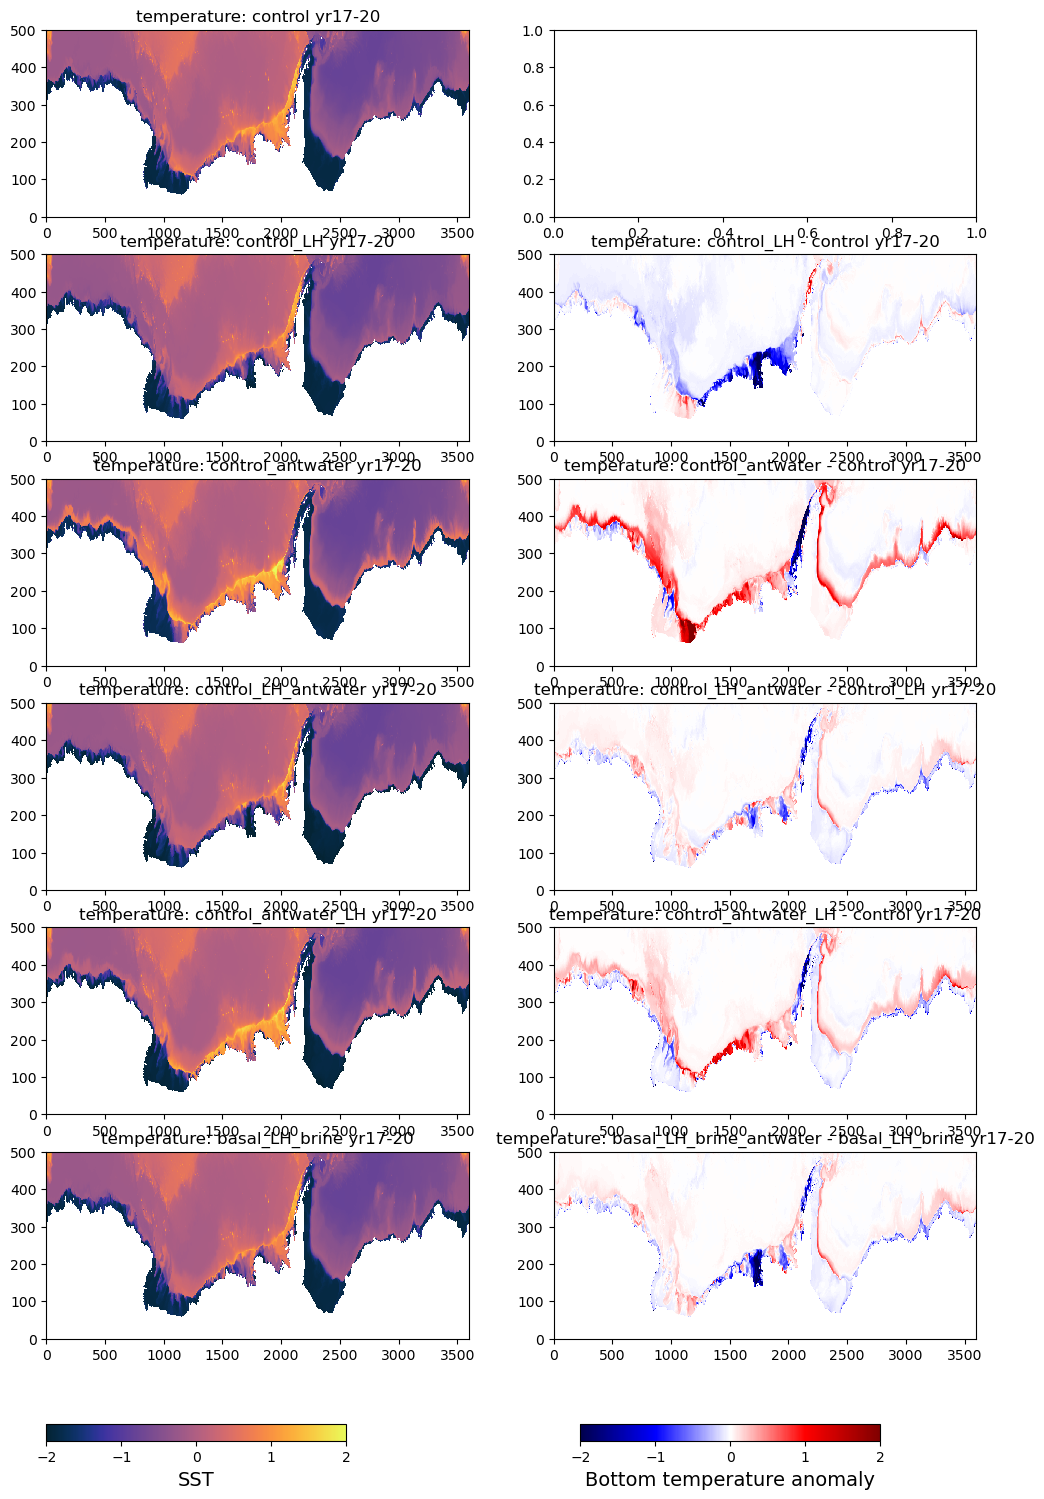

In [22]:
## Bottom temperature maps

fig, ax  = plt.subplots(nrows=6, ncols=2, figsize = (12,17))
ct=ax[0,0].pcolormesh(t1_bottom.mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[0,0].set_title('temperature: control yr17-20')
ax[0,0].set_ylim(0,500)
ax[1,0].pcolormesh(t1b_bottom.mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[1,0].set_title('temperature: control_LH yr17-20')
ax[1,0].set_ylim(0,500)
ax[2,0].pcolormesh(t1a_bottom.mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[2,0].set_title('temperature: control_antwater yr17-20')
ax[2,0].set_ylim(0,500)
ax[3,0].pcolormesh(t1a_b_bottom.mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[3,0].set_title('temperature: control_LH_antwater yr17-20')
ax[3,0].set_ylim(0,500)
ax[4,0].pcolormesh(t1a_c_bottom.mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[4,0].set_title('temperature: control_antwater_LH yr17-20')
ax[4,0].set_ylim(0,500)
ax[5,0].pcolormesh(t3_bottom.mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[5,0].set_title('temperature: basal_LH_brine yr17-20')
ax[5,0].set_ylim(0,500)

cta=ax[1,1].pcolormesh(t1b_bottom.mean('time').temp-
                   t1_bottom.mean('time').temp,vmin=-2,vmax=2, cmap='seismic')
ax[1,1].set_title('temperature: control_LH - control yr17-20')
ax[1,1].set_ylim(0,500)

cta=ax[2,1].pcolormesh(t1a_bottom.mean('time').temp-
                   t1_bottom.mean('time').temp,vmin=-2,vmax=2, cmap='seismic')
ax[2,1].set_title('temperature: control_antwater - control yr17-20')
ax[2,1].set_ylim(0,500)

ax[3,1].pcolormesh(t1a_b_bottom.mean('time').temp-
                   t1b_bottom.mean('time').temp,vmin=-2,vmax=2, cmap='seismic')
ax[3,1].set_title('temperature: control_LH_antwater - control_LH yr17-20')
ax[3,1].set_ylim(0,500)

ax[4,1].pcolormesh(t1a_c_bottom.mean('time').temp-
                   t1_bottom.mean('time').temp,vmin=-2,vmax=2, cmap='seismic')
ax[4,1].set_title('temperature: control_antwater_LH - control yr17-20')
ax[4,1].set_ylim(0,500)

ax[5,1].pcolormesh(t3a_bottom.mean('time').temp-
                   t3_bottom.mean('time').temp,vmin=-2,vmax=2, cmap='seismic')
ax[5,1].set_title('temperature: basal_LH_brine_antwater - basal_LH_brine yr17-20')
ax[5,1].set_ylim(0,500)

cax1 = fig.add_axes([0.125, 0.05, 0.25, 0.01])
cbar1=plt.colorbar(ct, cax=cax1, orientation='horizontal')#, shrink = 0.5, ticks = [0, 0.5, 1, 1.5, 2, 2.5, 3])
cbar1.set_label(r'SST', fontsize = 14)


cax2 = fig.add_axes([0.57, 0.05, 0.25, 0.01])
cbar2=plt.colorbar(cta, cax=cax2, orientation='horizontal')#, shrink = 0.5, ticks = [0, 0.5, 1, 1.5, 2, 2.5, 3])
cbar2.set_label(r'Bottom temperature anomaly', fontsize = 14)
plt.savefig(figdir+'Tbot_anoml_control_antwater_LH.png',bbox_inches='tight',dpi=300)
print(figdir+'Tbot_anoml_control_antwater_LH.png')

/g/data/e14/fbd581/basal_mom5-collaborative-project/Tbot_anoml_control_antwater_LH_v2.png


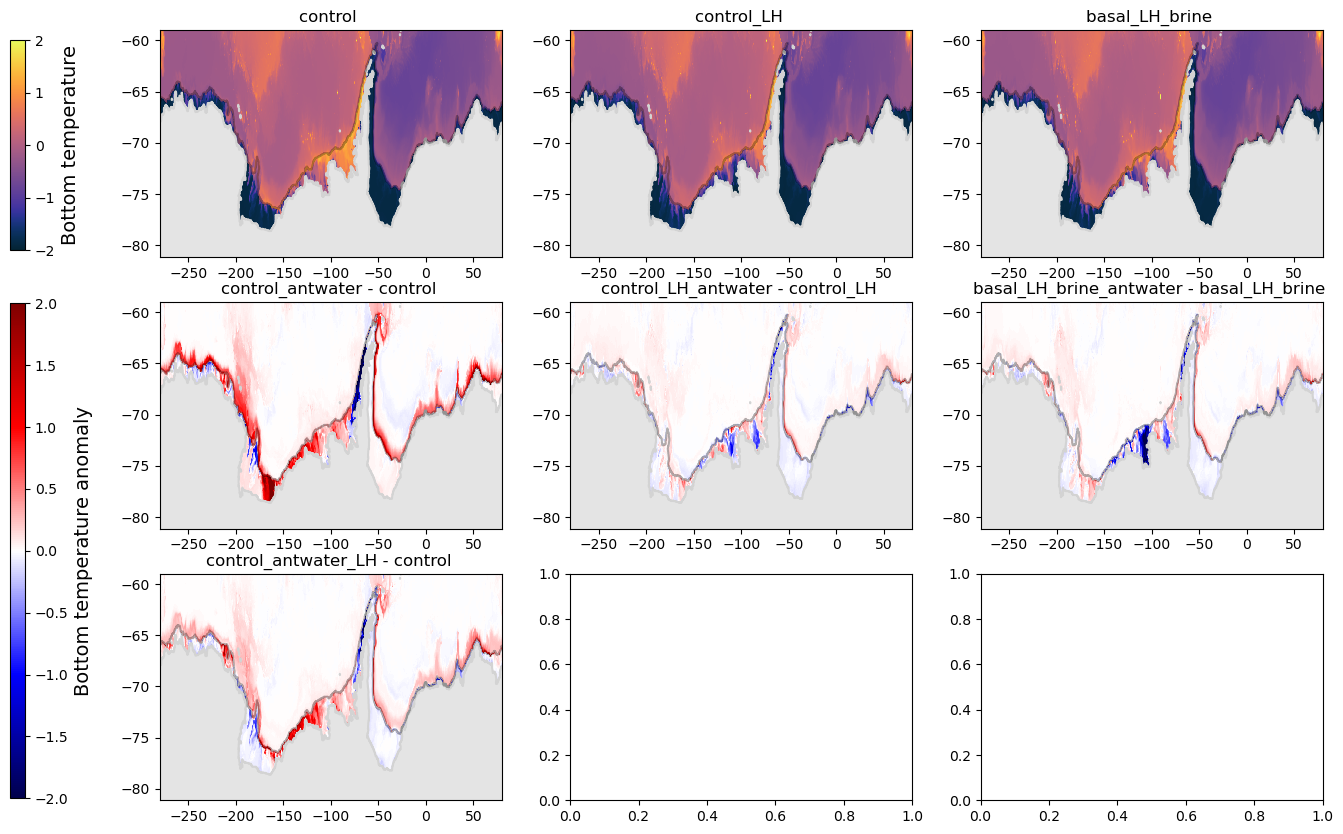

In [17]:
## Bottom temperature maps

fig, ax  = plt.subplots(nrows=3, ncols=3, figsize = (15,10))
ct=ax[0,0].pcolormesh(xt_ocean, yt_ocean,t1_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[0,0].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[0,0].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[0,0].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[0,0].set_title('control ')
ax[0,1].pcolormesh(xt_ocean, yt_ocean,t1b_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[0,1].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[0,1].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[0,1].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[0,1].set_title('control_LH ')
ax[0,2].pcolormesh(xt_ocean, yt_ocean,t3_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[0,2].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[0,2].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[0,2].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[0,2].set_title('basal_LH_brine ')

cta=ax[1,0].pcolormesh(xt_ocean, yt_ocean,t1a_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp-
                   t1_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp,vmin=-2,vmax=2, cmap='seismic')
ax[1,0].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[1,0].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[1,0].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[1,0].set_title('control_antwater - control ')

ax[1,1].pcolormesh(xt_ocean, yt_ocean,t1a_b_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp-
                   t1b_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp,vmin=-2,vmax=2, cmap='seismic')
ax[1,1].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[1,1].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[1,1].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[1,1].set_title('control_LH_antwater - control_LH ')

ax[2,0].pcolormesh(xt_ocean, yt_ocean,t1a_c_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp-
                   t1_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp,vmin=-2,vmax=2, cmap='seismic')
ax[2,0].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[2,0].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[2,0].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[2,0].set_title('control_antwater_LH - control ')

ax[1,2].pcolormesh(xt_ocean, yt_ocean,t3a_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp-
                   t3_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp,vmin=-2,vmax=2, cmap='seismic')
ax[1,2].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[1,2].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[1,2].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[1,2].set_title('basal_LH_brine_antwater - basal_LH_brine ')

cax1 = fig.add_axes([0.025, 0.66, 0.01, 0.21])
cbar1=plt.colorbar(ct, cax=cax1, orientation='vertical', shrink = 0.5)
cbar1.set_label(r'Bottom temperature', fontsize = 14)
cax2 = fig.add_axes([0.025, 0.112, 0.01, 0.495])
cbar2=plt.colorbar(cta, cax=cax2, orientation='vertical', shrink = 0.5)
cbar2.set_label(r'Bottom temperature anomaly', fontsize = 14)

plt.savefig(figdir+'Tbot_anoml_control_antwater_LH_v2.png',bbox_inches='tight',dpi=300)
print(figdir+'Tbot_anoml_control_antwater_LH_v2.png')

/g/data/e14/fbd581/basal_mom5-collaborative-project/Sbot_anoml_control_antwater_LH_v2.png


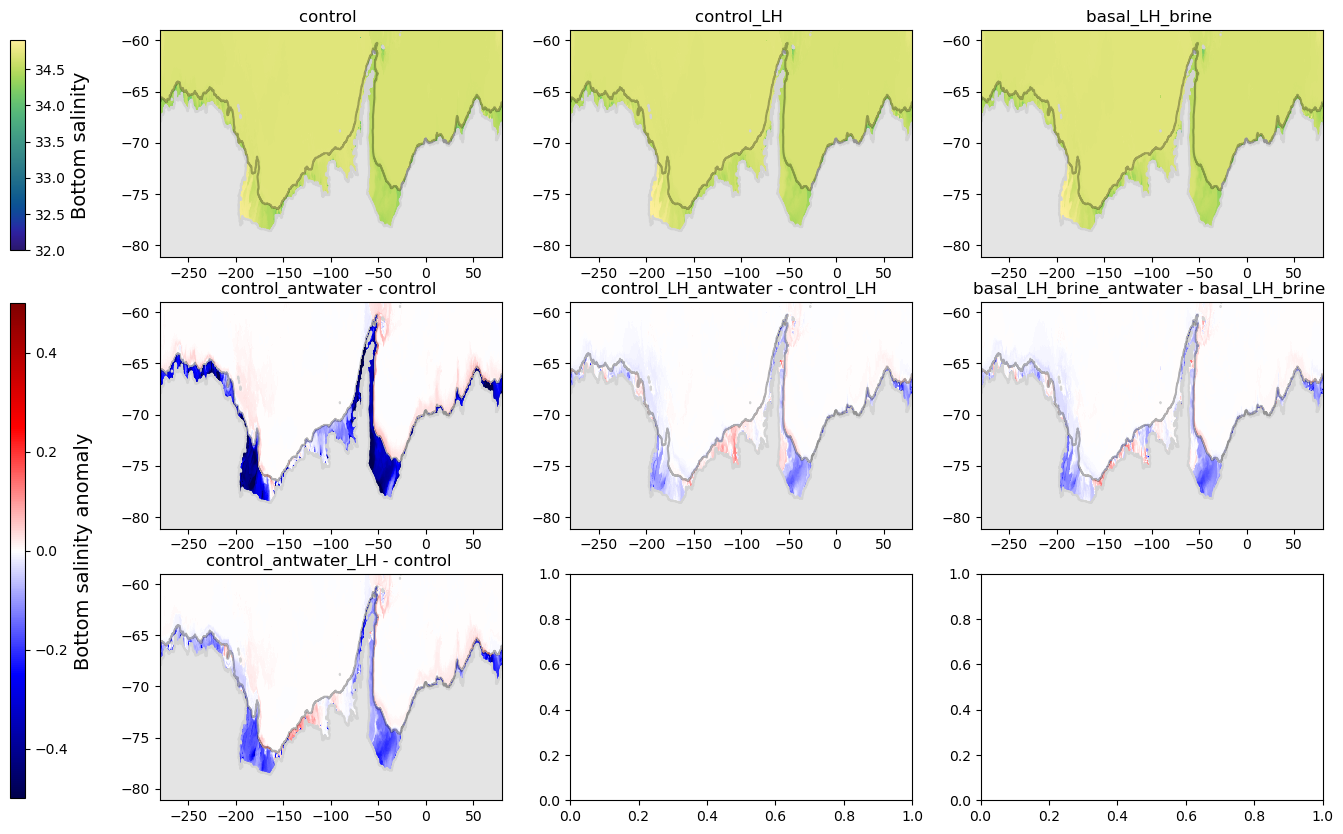

In [18]:
## Bottom salt maps

fig, ax  = plt.subplots(nrows=3, ncols=3, figsize = (15,10))
ct=ax[0,0].pcolormesh(xt_ocean, yt_ocean,s1_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt,vmin=32,vmax=34.9, cmap=cmo.cm.haline)
ax[0,0].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[0,0].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[0,0].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[0,0].set_title('control ')
ax[0,1].pcolormesh(xt_ocean, yt_ocean,s1b_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt,vmin=32,vmax=34.9, cmap=cmo.cm.haline)
ax[0,1].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[0,1].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[0,1].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[0,1].set_title('control_LH ')
ax[0,2].pcolormesh(xt_ocean, yt_ocean,s3_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt,vmin=32,vmax=34.9, cmap=cmo.cm.haline)
ax[0,2].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[0,2].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[0,2].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[0,2].set_title('basal_LH_brine ')

cta=ax[1,0].pcolormesh(xt_ocean, yt_ocean,s1a_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt-
                   s1_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt,vmin=-.5,vmax=.5, cmap='seismic')
ax[1,0].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[1,0].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[1,0].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[1,0].set_title('control_antwater - control ')

ax[1,1].pcolormesh(xt_ocean, yt_ocean,s1a_b_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt-
                   s1b_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt,vmin=-.5,vmax=.5, cmap='seismic')
ax[1,1].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[1,1].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[1,1].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[1,1].set_title('control_LH_antwater - control_LH ')

ax[2,0].pcolormesh(xt_ocean, yt_ocean,s1a_c_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt-
                   s1_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt,vmin=-.5,vmax=.5, cmap='seismic')
ax[2,0].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[2,0].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[2,0].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[2,0].set_title('control_antwater_LH - control ')

ax[1,2].pcolormesh(xt_ocean, yt_ocean,s3a_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt-
                   s3_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt,vmin=-.5,vmax=.5, cmap='seismic')
ax[1,2].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[1,2].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[1,2].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[1,2].set_title('basal_LH_brine_antwater - basal_LH_brine ')

cax1 = fig.add_axes([0.025, 0.66, 0.01, 0.21])
cbar1=plt.colorbar(ct, cax=cax1, orientation='vertical', shrink = 0.5)
cbar1.set_label(r'Bottom salinity', fontsize = 14)
cax2 = fig.add_axes([0.025, 0.112, 0.01, 0.495])
cbar2=plt.colorbar(cta, cax=cax2, orientation='vertical', shrink = 0.5)
cbar2.set_label(r'Bottom salinity anomaly', fontsize = 14)

plt.savefig(figdir+'Sbot_anoml_control_antwater_LH_v2.png',bbox_inches='tight',dpi=300)
print(figdir+'Sbot_anoml_control_antwater_LH_v2.png')

### Repeat Bottom Maps with a zoom in the AMUD-BELLS

/g/data/e14/fbd581/basal_mom5-collaborative-project/Tbot_anoml_control_antwater_LH_WAnt.png


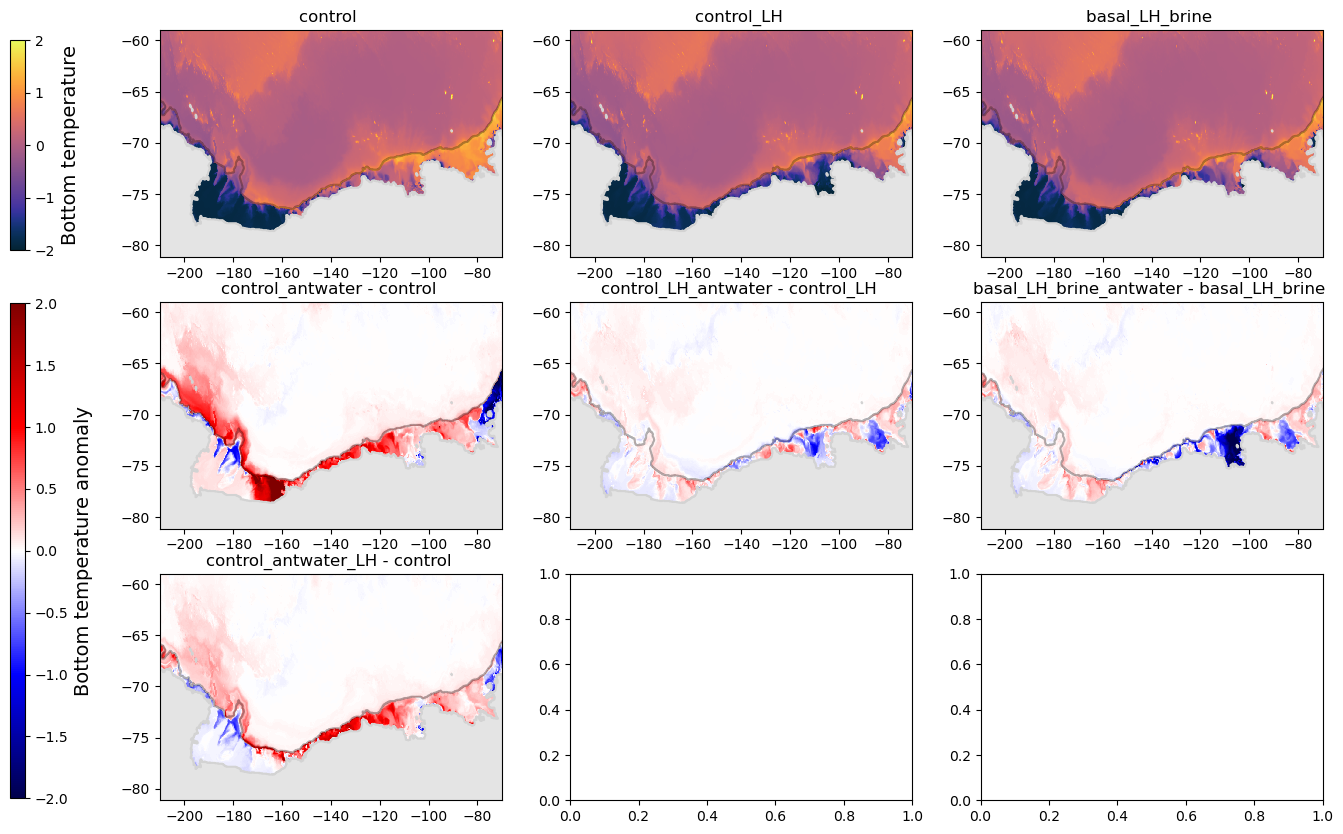

In [21]:
## Bottom temperature maps

fig, ax  = plt.subplots(nrows=3, ncols=3, figsize = (15,10))
ct=ax[0,0].pcolormesh(xt_ocean, yt_ocean,t1_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[0,0].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[0,0].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[0,0].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[0,0].set_title('control ')
ax[0,0].set_xlim(-210,-70)

ax[0,1].pcolormesh(xt_ocean, yt_ocean,t1b_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[0,1].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[0,1].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[0,1].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[0,1].set_title('control_LH ')
ax[0,1].set_xlim(-210,-70)

ax[0,2].pcolormesh(xt_ocean, yt_ocean,t3_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[0,2].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[0,2].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[0,2].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[0,2].set_title('basal_LH_brine ')
ax[0,2].set_xlim(-210,-70)

cta=ax[1,0].pcolormesh(xt_ocean, yt_ocean,t1a_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp-
                   t1_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp,vmin=-2,vmax=2, cmap='seismic')
ax[1,0].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[1,0].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[1,0].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[1,0].set_title('control_antwater - control ')
ax[1,0].set_xlim(-210,-70)

ax[1,1].pcolormesh(xt_ocean, yt_ocean,t1a_b_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp-
                   t1b_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp,vmin=-2,vmax=2, cmap='seismic')
ax[1,1].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[1,1].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[1,1].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[1,1].set_title('control_LH_antwater - control_LH ')
ax[1,1].set_xlim(-210,-70)

ax[2,0].pcolormesh(xt_ocean, yt_ocean,t1a_c_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp-
                   t1_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp,vmin=-2,vmax=2, cmap='seismic')
ax[2,0].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[2,0].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[2,0].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[2,0].set_title('control_antwater_LH - control ')
ax[2,0].set_xlim(-210,-70)

ax[1,2].pcolormesh(xt_ocean, yt_ocean,t3a_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp-
                   t3_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').temp,vmin=-2,vmax=2, cmap='seismic')
ax[1,2].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[1,2].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[1,2].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[1,2].set_title('basal_LH_brine_antwater - basal_LH_brine ')
ax[1,2].set_xlim(-210,-70)

cax1 = fig.add_axes([0.025, 0.66, 0.01, 0.21])
cbar1=plt.colorbar(ct, cax=cax1, orientation='vertical', shrink = 0.5)
cbar1.set_label(r'Bottom temperature', fontsize = 14)
cax2 = fig.add_axes([0.025, 0.112, 0.01, 0.495])
cbar2=plt.colorbar(cta, cax=cax2, orientation='vertical', shrink = 0.5)
cbar2.set_label(r'Bottom temperature anomaly', fontsize = 14)

plt.savefig(figdir+'Tbot_anoml_control_antwater_LH_Want.png',bbox_inches='tight',dpi=300)
print(figdir+'Tbot_anoml_control_antwater_LH_WAnt.png')

/g/data/e14/fbd581/basal_mom5-collaborative-project/Sbot_anoml_control_antwater_LH_WAnt.png


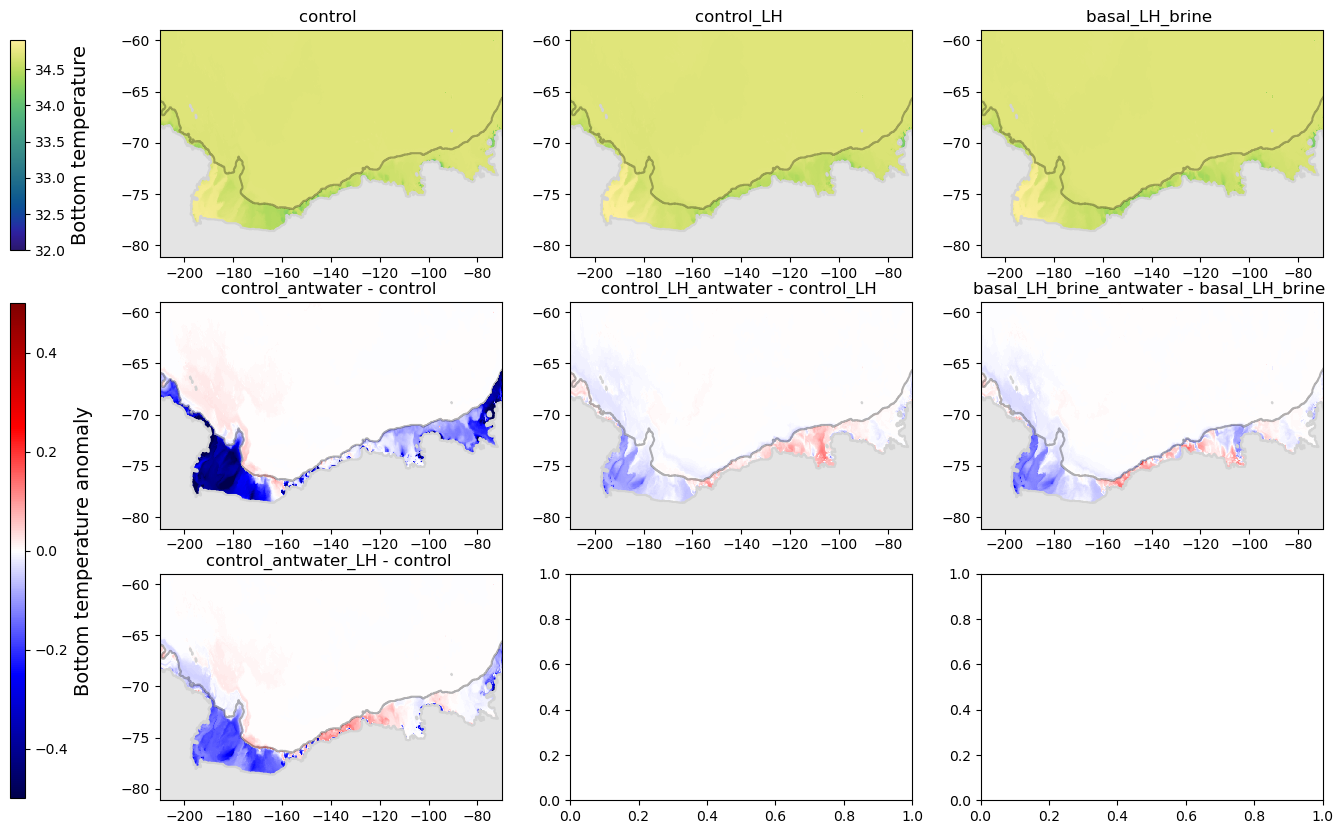

In [22]:
## Bottom salinity maps

fig, ax  = plt.subplots(nrows=3, ncols=3, figsize = (15,10))
ct=ax[0,0].pcolormesh(xt_ocean, yt_ocean,s1_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt,vmin=32,vmax=34.9, cmap=cmo.cm.haline)
ax[0,0].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[0,0].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[0,0].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[0,0].set_title('control ')
ax[0,0].set_xlim(-210,-70)

ax[0,1].pcolormesh(xt_ocean, yt_ocean,s1b_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt,vmin=32,vmax=34.9, cmap=cmo.cm.haline)
ax[0,1].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[0,1].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[0,1].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[0,1].set_title('control_LH ')
ax[0,1].set_xlim(-210,-70)

ax[0,2].pcolormesh(xt_ocean, yt_ocean,s3_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt,vmin=32,vmax=34.9, cmap=cmo.cm.haline)
ax[0,2].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[0,2].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[0,2].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[0,2].set_title('basal_LH_brine ')
ax[0,2].set_xlim(-210,-70)

cta=ax[1,0].pcolormesh(xt_ocean, yt_ocean,s1a_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt-
                   s1_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt,vmin=-.5,vmax=.5, cmap='seismic')
ax[1,0].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[1,0].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[1,0].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[1,0].set_title('control_antwater - control ')
ax[1,0].set_xlim(-210,-70)

ax[1,1].pcolormesh(xt_ocean, yt_ocean,s1a_b_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt-
                   s1b_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt,vmin=-.5,vmax=.5, cmap='seismic')
ax[1,1].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[1,1].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[1,1].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[1,1].set_title('control_LH_antwater - control_LH ')
ax[1,1].set_xlim(-210,-70)

ax[2,0].pcolormesh(xt_ocean, yt_ocean,s1a_c_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt-
                   s1_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt,vmin=-.5,vmax=.5, cmap='seismic')
ax[2,0].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[2,0].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[2,0].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[2,0].set_title('control_antwater_LH - control ')
ax[2,0].set_xlim(-210,-70)

ax[1,2].pcolormesh(xt_ocean, yt_ocean,s3a_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt-
                   s3_bottom.sel(yt_ocean = slice(-90, -59)).mean('time').salt,vmin=-.5,vmax=.5, cmap='seismic')
ax[1,2].contourf(xt_ocean, yt_ocean, land_mask['ht'], [0.9, 1],colors = 'lightgray', alpha = 0.6 )
ax[1,2].contour(xt_ocean, yt_ocean, land_mask['ht'], [0, 1],colors = 'lightgray', alpha = 1. )
ax[1,2].contour(shelf_mask.xt_ocean, shelf_mask.yt_ocean, shelf_mask, [0, 1],colors='k', alpha = 0.3)
ax[1,2].set_title('basal_LH_brine_antwater - basal_LH_brine ')
ax[1,2].set_xlim(-210,-70)

cax1 = fig.add_axes([0.025, 0.66, 0.01, 0.21])
cbar1=plt.colorbar(ct, cax=cax1, orientation='vertical', shrink = 0.5)
cbar1.set_label(r'Bottom temperature', fontsize = 14)
cax2 = fig.add_axes([0.025, 0.112, 0.01, 0.495])
cbar2=plt.colorbar(cta, cax=cax2, orientation='vertical', shrink = 0.5)
cbar2.set_label(r'Bottom temperature anomaly', fontsize = 14)

plt.savefig(figdir+'Sbot_anoml_control_antwater_LH_Want.png',bbox_inches='tight',dpi=300)
print(figdir+'Sbot_anoml_control_antwater_LH_WAnt.png')

In [ ]:
# plt.figure
plt.pcolormesh(t1.isel(time=slice(204,240),st_ocean=0).mean('time').temp-t1b.isel(time=slice(201,237),st_ocean=0).mean('time').temp,vmin=-.5,vmax=.5, cmap='seismic')
plt.colorbar()
# plt.ylim(0,600)

# difference control - control_LH global
# average of the years 17-20:

In [ ]:
fig, ax  = plt.subplots(nrows=3, ncols=2, figsize = (12,14))
ax[0,0].pcolormesh(t1.isel(time=slice(204,240),st_ocean=0).mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[0,1].pcolormesh(t1b.isel(time=slice(201,237),st_ocean=0).mean('time').temp-273.15,vmin=-2,vmax=2, cmap=cmo.cm.thermal)
ax[1,0].pcolormesh(s1.isel(time=slice(204,240),st_ocean=0).mean('time').salt,vmin=32,vmax=35, cmap=cmo.cm.haline)
ax[1,1].pcolormesh(s1b.isel(time=slice(201,237),st_ocean=0).mean('time').salt,vmin=32,vmax=35, cmap=cmo.cm.haline)
ax[2,0].pcolormesh(t1.isel(time=slice(204,240),st_ocean=0).mean('time').temp-
                   t1b.isel(time=slice(201,237),st_ocean=0).mean('time').temp,vmin=-2,vmax=2, cmap=cmo.cm.balance)
ax[2,1].pcolormesh(s1.isel(time=slice(204,240),st_ocean=0).mean('time').salt-
                   s1b.isel(time=slice(201,237),st_ocean=0).mean('time').salt,vmin=-.5,vmax=.5, cmap=cmo.cm.balance)


In [ ]:
plt.pcolormesh(t1.isel(time=slice(216,240),st_ocean=0).mean('time').temp-t1s.isel(time=slice(96,120),st_ocean=0).mean('time').temp,vmin=-.5,vmax=.5, cmap='seismic')
plt.colorbar()
# plt.ylim(0,600)

# average of the years 18-20:

#### basal noGade: SST partI vs SOFIA

In [ ]:
plt.pcolormesh(t2.isel(time=slice(216,240),st_ocean=0).mean('time').temp-t2s.isel(time=slice(96,120),st_ocean=0).mean('time').temp,vmin=-.5,vmax=.5, cmap='seismic')
plt.colorbar()
# plt.ylim(0,600)

# average of the years 18-20:

#### Basal_LH_Brine: SST partI vs SOFIA

In [ ]:
plt.pcolormesh(t3.isel(time=slice(216,240),st_ocean=0).mean('time').temp-t3s.isel(time=slice(96,120),st_ocean=0).mean('time').temp,vmin=-.5,vmax=.5, cmap='seismic')
plt.colorbar()
# plt.ylim(0,600)

# average of the years 18-20:

#### Look at salinity:

In [ ]:
## plot all together:
## Combine all these in one plot:

fig = plt.figure(figsize=(16,15))

ax1 = fig.add_subplot(3,3,1)
plt.pcolormesh(s1.isel(time=slice(216,240),st_ocean=0).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Control yr18-20 annual mean')

ax1 = fig.add_subplot(3,3,2)
plt.pcolormesh(s1.isel(time=slice(216,240),st_ocean=0).mean('time').salt
              -s1s.isel(time=slice(96,120),st_ocean=0).mean('time').salt
              ,cmap='seismic')
plt.colorbar()
plt.clim(-1.,1.)
plt.ylim(0,500)
plt.title('Difference Control - SSP1-2.6 ')

ax1 = fig.add_subplot(3,3,3)
plt.pcolormesh(s1.isel(time=slice(216,240),st_ocean=0).mean('time').salt
              -s1a.isel(time=slice(99,123),st_ocean=0).mean('time').salt
              ,cmap='seismic')
plt.colorbar()
plt.clim(-1.,1.)
plt.ylim(0,500)
plt.title('Difference Control - Antwater ')

# Basal
ax1 = fig.add_subplot(3,3,4)
plt.pcolormesh(s2.isel(time=slice(216,240),st_ocean=0).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Basal yr18-20 annual mean')

ax1 = fig.add_subplot(3,3,5)
plt.pcolormesh(s2.isel(time=slice(216,240),st_ocean=0).mean('time').salt
              -s2s.isel(time=slice(96,120),st_ocean=0).mean('time').salt
              ,cmap='seismic')
plt.colorbar()
plt.clim(-1.,1.)
plt.ylim(0,500)
plt.title('Difference Basal - SSP1-2.6 ')

# Basal_LH_Brine
ax1 = fig.add_subplot(3,3,7)
plt.pcolormesh(s3.isel(time=slice(213,240),st_ocean=0).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Basal_LH_Brine - yr18-20')

ax1 = fig.add_subplot(3,3,8)
plt.pcolormesh(s3.isel(time=slice(213,240),st_ocean=0).mean('time').salt
              -s3s.isel(time=slice(96,120),st_ocean=0).mean('time').salt
              ,cmap='seismic')
plt.colorbar()
plt.clim(-1.,1.)
plt.ylim(0,500)
plt.title('Difference Basal_LH_Brine - SSP1-2.6 ')

ax1 = fig.add_subplot(3,3,9)
plt.pcolormesh(s3.isel(time=slice(216,240),st_ocean=0).mean('time').salt
              -s3a.isel(time=slice(2,50),st_ocean=0).mean('time').salt
              ,cmap='seismic')
plt.colorbar()
plt.clim(-1.,1.)
plt.ylim(0,500)
plt.title('Difference Basal_LH_Brine - Antwater ')

fig_path = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'
name_fig='SSS_comparison_ctrlxSOFIA-Antwater_yr18-20.png'
plt.savefig(fig_path + name_fig, dpi=300, bbox_inches='tight')

In [ ]:
## plot all together:
## Combine all these in one plot:

fig = plt.figure(figsize=(16,15))

ax1 = fig.add_subplot(5,3,1)
plt.pcolormesh(s1.isel(time=slice(216,240),st_ocean=0).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Control yr18-20 annual mean')

ax1 = fig.add_subplot(5,3,2)
plt.pcolormesh(s1s.isel(time=slice(96,120),st_ocean=0).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('SSP1-2.6 yr18-20 annual mean')

ax1 = fig.add_subplot(5,3,3)
plt.pcolormesh(s1.isel(time=slice(216,240),st_ocean=0).mean('time').salt
              -s1s.isel(time=slice(96,120),st_ocean=0).mean('time').salt
              ,cmap='seismic')
plt.colorbar()
plt.clim(-1.,1.)
plt.ylim(0,500)
plt.title('Difference Control - SSP1-2.6 ')

# Basal
ax1 = fig.add_subplot(5,3,4)
plt.pcolormesh(s2.isel(time=slice(216,240),st_ocean=0).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Basal yr18-20 annual mean')

ax1 = fig.add_subplot(5,3,5)
plt.pcolormesh(s2s.isel(time=slice(96,120),st_ocean=0).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Basal-SSP1-2.6 yr18-20 annual mean')

ax1 = fig.add_subplot(5,3,6)
plt.pcolormesh(s2.isel(time=slice(216,240),st_ocean=0).mean('time').salt
              -s2s.isel(time=slice(96,120),st_ocean=0).mean('time').salt
              ,cmap='seismic')
plt.colorbar()
plt.clim(-1.,1.)
plt.ylim(0,500)
plt.title('Difference Basal - SSP1-2.6 ')

# Basal_LH_Brine
ax1 = fig.add_subplot(5,3,7)
plt.pcolormesh(s3.isel(time=slice(213,240),st_ocean=0).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Basal_LH_Brine - yr18-20')

ax1 = fig.add_subplot(5,3,8)
plt.pcolormesh(s3s.isel(time=slice(96,120),st_ocean=0).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Basal_LH_Brine-SSP1-2.6 - yr18-20')

ax1 = fig.add_subplot(5,3,9)
plt.pcolormesh(s3.isel(time=slice(213,240),st_ocean=0).mean('time').salt
              -s3s.isel(time=slice(96,120),st_ocean=0).mean('time').salt
              ,cmap='seismic')
plt.colorbar()
plt.clim(-1.,1.)
plt.ylim(0,500)
plt.title('Difference Basal_LH_Brine - SSP1-2.6 ')

# Control antwater
ax1 = fig.add_subplot(5,3,11)
plt.pcolormesh(s1a.isel(time=slice(99,123),st_ocean=0).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Antwater yr18-20 annual mean')

ax1 = fig.add_subplot(5,3,12)
plt.pcolormesh(s1.isel(time=slice(216,240),st_ocean=0).mean('time').salt
              -s1a.isel(time=slice(99,123),st_ocean=0).mean('time').salt
              ,cmap='seismic')
plt.colorbar()
plt.clim(-1.,1.)
plt.ylim(0,500)
plt.title('Difference Control - Antwater ')

# BGB antwater
ax1 = fig.add_subplot(5,3,14)
plt.pcolormesh(s3a.isel(time=slice(2,50),st_ocean=0).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Basal_LH_Brine-Antwater \n yr18-20 annual mean')

ax1 = fig.add_subplot(5,3,15)
plt.pcolormesh(s3.isel(time=slice(216,240),st_ocean=0).mean('time').salt
              -s3a.isel(time=slice(2,50),st_ocean=0).mean('time').salt
              ,cmap='seismic')
plt.colorbar()
plt.clim(-1.,1.)
plt.ylim(0,500)
plt.title('Difference Basal_LH_Brine - Antwater ')

fig_path = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'
name_fig='SSS_comparison_ctrlxSOFIA_yr18-20.png'
plt.savefig(fig_path + name_fig, dpi=300, bbox_inches='tight')

In [ ]:
## plot all together:
## Combine all these in one plot:

fig = plt.figure(figsize=(16,10))

ax1 = fig.add_subplot(3,3,1)
plt.pcolormesh(s1.isel(time=slice(216,240),st_ocean=0).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Control yr18-20 annual mean')

ax1 = fig.add_subplot(3,3,2)
plt.pcolormesh(s2.isel(time=slice(216,240),st_ocean=0).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Basal yr18-20 annual mean')

ax1 = fig.add_subplot(3,3,3)
plt.pcolormesh(s3.isel(time=slice(213,240),st_ocean=0).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Basal_LH_Brine yr18-20 annual mean')

ax1 = fig.add_subplot(3,3,5)
plt.pcolormesh(s2.isel(time=slice(216,240),st_ocean=0).mean('time').salt
              -s1.isel(time=slice(216,240),st_ocean=0).mean('time').salt
              ,cmap='seismic')
plt.colorbar()
plt.clim(-.5,.5)
plt.ylim(0,500)
plt.title('Difference Basal - Control ')


ax1 = fig.add_subplot(3,3,6)
plt.pcolormesh(s3.isel(time=slice(213,240),st_ocean=0).mean('time').salt
              -s1.isel(time=slice(216,240),st_ocean=0).mean('time').salt
              ,cmap='seismic')
plt.colorbar()
plt.clim(-.5,.5)
plt.ylim(0,500)
plt.title('Difference Basal_LH_Brine - Control')

fig_path = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'
name_fig='SSS_comparison_ctrlXbasal_yr18-20.png'
plt.savefig(fig_path + name_fig, dpi=300, bbox_inches='tight')

#### Bottom temperature/salinity changes:

In [ ]:
## plot all together:
## Combine all these in one plot:

fig = plt.figure(figsize=(16,10))

ax1 = fig.add_subplot(3,3,1)
plt.pcolormesh(s1.isel(time=slice(204,240),st_ocean=-1).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Control yr18-20 annual mean')

ax1 = fig.add_subplot(3,3,2)
plt.pcolormesh(s2.isel(time=slice(204,240),st_ocean=-1).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Basal yr18-20 annual mean')

ax1 = fig.add_subplot(3,3,3)
plt.pcolormesh(s3.isel(time=slice(204,240),st_ocean=-1).mean('time').salt)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Basal_LH_Brine yr18-20 annual mean')

ax1 = fig.add_subplot(3,3,5)
plt.pcolormesh(s2.isel(time=slice(204,240),st_ocean=-1).mean('time').salt
              -s1.isel(time=slice(204,240),st_ocean=-1).mean('time').salt
              ,cmap='seismic')
plt.colorbar()
plt.clim(-.5,.5)
plt.ylim(0,500)
plt.title('Difference Basal - Control ')


ax1 = fig.add_subplot(3,3,6)
plt.pcolormesh(s3.isel(time=slice(204,240),st_ocean=-1).mean('time').salt
              -s1.isel(time=slice(204,240),st_ocean=-1).mean('time').salt
              ,cmap='seismic')
plt.colorbar()
plt.clim(-.5,.5)
plt.ylim(0,500)
plt.title('Difference Basal_LH_Brine - Control')

fig_path = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'
name_fig='BottomSalt_comparison_ctrlXbasal_yr17-20.png'
plt.savefig(fig_path + name_fig, dpi=300, bbox_inches='tight')

In [ ]:
plt.pcolormesh(s1.isel(time=slice(204,240),st_ocean=30).mean('time').salt)


In [ ]:
d2 = cat.search(variable="ht",path='/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output000/ocean/ocean_grid.nc').to_dask()

plt.pcolormesh(d2.ht)
plt.colorbar()

In [ ]:
st_ocean = cat.search(variable='st_ocean', frequency='1mon', file_id='ocean').to_dask()

In [ ]:
st_ocean

In [ ]:
## plot all together:
## Combine all these in one plot:

fig = plt.figure(figsize=(16,10))

ax1 = fig.add_subplot(3,3,1)
plt.pcolormesh(t1.isel(time=slice(204,240),st_ocean=-1).mean('time').temp)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Control yr18-20 annual mean')

ax1 = fig.add_subplot(3,3,2)
plt.pcolormesh(t2.isel(time=slice(204,240),st_ocean=-1).mean('time').temp)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Basal yr18-20 annual mean')

ax1 = fig.add_subplot(3,3,3)
plt.pcolormesh(t3.isel(time=slice(204,240),st_ocean=-1).mean('time').temp)
plt.colorbar()
plt.clim(33,35)
plt.ylim(0,500)
plt.title('Basal_LH_Brine yr18-20 annual mean')

ax1 = fig.add_subplot(3,3,5)
plt.pcolormesh(t2.isel(time=slice(204,240),st_ocean=-1).mean('time').temp
              -s1.isel(time=slice(204,240),st_ocean=-1).mean('time').temp
              ,cmap='seismic')
plt.colorbar()
plt.clim(-.5,.5)
plt.ylim(0,500)
plt.title('Difference Basal - Control ')


ax1 = fig.add_subplot(3,3,6)
plt.pcolormesh(t3.isel(time=slice(204,240),st_ocean=-1).mean('time').temp
              -s1.isel(time=slice(204,240),st_ocean=-1).mean('time').temp
              ,cmap='seismic')
plt.colorbar()
plt.clim(-.5,.5)
plt.ylim(0,500)
plt.title('Difference Basal_LH_Brine - Control')

# fig_path = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'
# name_fig='BottomTemp_comparison_ctrlXbasal_yr17-20.png'
# plt.savefig(fig_path + name_fig, dpi=300, bbox_inches='tight')

### Look at the runoff:

In [ ]:
plt.pcolormesh(d1.isel(time=slice(216,240)).mean('time').runoff-d1s.isel(time=slice(96,120)).mean('time').runoff
               ,cmap='seismic')
plt.colorbar()
plt.clim(-.00001,.00001)




In [ ]:
plt.pcolormesh(d2b['basal_fwflx2d'].isel(time=slice(120,132)).mean('time')-d2b_s['basal_fwflx2d'].isel(time=slice(0,12)).mean('time')
               ,cmap='seismic')
plt.colorbar()
plt.clim(-.000001,.000001)


In [ ]:
plt.pcolormesh(d3b['basal_fwflx2d'].isel(time=slice(213,240)).mean('time')-d3b_s['basal_fwflx2d'].isel(time=slice(96,120)).mean('time')
               ,cmap='seismic')
plt.colorbar()
plt.clim(-.000001,.000001)


note: use the basal_flx or some other variable to compare in the basal(nogade) and basal_LH_Brine

#### plot runoff timeseries comparison across experiments:

In [ ]:
%%time
### runoff horizontally integrated:
runoff_ctrl = d1['runoff'].sum('yt_ocean').sum('xt_ocean').load()
runoff_noBG = d2['runoff'].sum('yt_ocean').sum('xt_ocean').load()
runoff_BGB = d3['runoff'].sum('yt_ocean').sum('xt_ocean').load()

In [ ]:
%%time
basal_noBG = d2b['basal_fwflx2d'].sum('yt_ocean').sum('xt_ocean').load()


In [ ]:
basal_BGB = d3b['basal_fwflx2d'].sum('yt_ocean').sum('xt_ocean').load()


In [ ]:
%%time
runoff_ctrl_s = d1s['runoff'].sum('yt_ocean').sum('xt_ocean').load()
runoff_noBG_s = d2s['runoff'].sum('yt_ocean').sum('xt_ocean').load()
runoff_BGB_s = d3s['runoff'].sum('yt_ocean').sum('xt_ocean').load()


In [ ]:
basal_noBG_s = d2b_s['basal_fwflx2d'].sum('yt_ocean').sum('xt_ocean').load()
basal_BGB_s = d3b_s['basal_fwflx2d'].sum('yt_ocean').sum('xt_ocean').load()


In [ ]:
# start_time='1910-01-01'
# end_time='1913-01-01'
# # .sel(time=slice(start_time,end_time))

In [ ]:
plt.plot(runoff_ctrl, 'k:', label='ctrl')#.time, runoff_ctrl)
plt.plot(runoff_ctrl_s, 'r:', label='ctrl SOFIA')#.time, runoff_ctrl_s)
plt.plot(runoff_ctrl_s-runoff_ctrl,'--',color='orange',label='diff')
plt.legend(loc='best')
plt.title('Control')
plt.grid('on')
plt.ylim(-5,60)

In [ ]:
plt.plot(runoff_noBG, 'k:', label='runoff')#.time, runoff_noBG)
plt.plot(basal_noBG, 'k--', label='basal_flx ')
plt.plot(runoff_noBG_s, 'r:', label='runoff SOFIA')#.time, runoff_noBG_s)
plt.plot(basal_noBG_s, 'r--', label='basal_flx SOFIA')
plt.legend(loc='best')
plt.title('Basal (noGade)')
plt.grid('on')
plt.ylim(-5,60)

In [ ]:
plt.plot(runoff_BGB, 'k:', label='runoff')#.time, runoff_noBG)
plt.plot(basal_BGB, 'k--', label='basal_flx ')
plt.plot(runoff_BGB_s, 'r:', label='runoff SOFIA')#.time, runoff_noBG_s)
plt.plot(basal_BGB_s, 'r--', label='basal_flx SOFIA')
plt.legend(loc='best')
plt.title('Basal_LH_Brine')
plt.grid('on')
plt.ylim(-5,60)

In [ ]:
print(runoff_ctrl.mean('time'))
print(runoff_ctrl_s.mean('time'))
print(runoff_noBG.mean('time')+ basal_noBG.mean('time'))
print(runoff_noBG_s.mean('time')+ basal_noBG_s.mean('time'))
print(runoff_BGB.mean('time') + basal_BGB.mean('time'))
print(runoff_BGB_s.mean('time') + basal_BGB_s.mean('time'))

In [ ]:
plt.plot(runoff_ctrl_s, 'k', label='ctrl')#.time, runoff_ctrl)
plt.plot(runoff_noBG_s, 'r--', label='Basal')#.time, runoff_noBG)
plt.plot(runoff_BGB_s, 'b:', label='Basal_LH_Brine')#.time, runoff_noBG)
# plt.xlim(150,250)
plt.legend()
plt.title('Total runoff (runoff+basal), SOFIA experiments (part 2)')
plt.ylim(-5,60)

In [ ]:
plt.plot(runoff_ctrl, 'k', label='ctrl')#.time, runoff_ctrl)
plt.plot(runoff_noBG, 'b:', label='Basal')#.time, runoff_noBG)
plt.ylim(-5,60)

### Look at the surface salinity restoring flux:

In [ ]:
## Combine all these in one plot:

fig = plt.figure(figsize=(16,10))

ax1 = fig.add_subplot(3,3,1)
plt.pcolormesh(sr1.isel(time=slice(216,240)).mean('time').sfc_salt_flux_restore, cmap='bwr')
plt.colorbar()
plt.clim(-7e-7,7e-7)
plt.ylim(0,500)
plt.title('Control yr18-20')

ax1 = fig.add_subplot(3,3,2)
plt.pcolormesh(sr1s.isel(time=slice(96,120)).mean('time').sfc_salt_flux_restore, cmap='bwr')
plt.colorbar()
plt.clim(-7e-7,7e-7)
plt.ylim(0,500)
plt.title('SSP1-2.6 yr18-20')

ax1 = fig.add_subplot(3,3,3)
plt.pcolormesh(sr1.isel(time=slice(216,240)).mean('time').sfc_salt_flux_restore
              -sr1s.isel(time=slice(96,120)).mean('time').sfc_salt_flux_restore
              ,cmap='seismic')
plt.colorbar()
plt.clim(-7e-7,7e-7)
plt.ylim(0,500)
plt.title('Difference Control - SSP1-2.6 ')

# Basal
ax1 = fig.add_subplot(3,3,4)
plt.pcolormesh(sr2.isel(time=slice(216,240)).mean('time').sfc_salt_flux_restore, cmap='bwr')
plt.colorbar()
plt.clim(-7e-7,7e-7)
plt.ylim(0,500)
plt.title('Basal yr18-20')

ax1 = fig.add_subplot(3,3,5)
plt.pcolormesh(sr2s.isel(time=slice(96,120)).mean('time').sfc_salt_flux_restore, cmap='bwr')
plt.colorbar()
plt.clim(-7e-7,7e-7)
plt.ylim(0,500)
plt.title('Basal-SSP1-2.6 yr18-20')

ax1 = fig.add_subplot(3,3,6)
plt.pcolormesh(sr2.isel(time=slice(216,240)).mean('time').sfc_salt_flux_restore
              -sr2s.isel(time=slice(96,120)).mean('time').sfc_salt_flux_restore
              ,cmap='seismic')
plt.colorbar()
plt.clim(-7e-7,7e-7)
plt.ylim(0,500)
plt.title('Difference Basal - SSP1-2.6 ')

# Basal_LH_Brine
ax1 = fig.add_subplot(3,3,7)
plt.pcolormesh(sr3.isel(time=slice(213,240)).mean('time').sfc_salt_flux_restore, cmap='bwr')
plt.colorbar()
plt.clim(-7e-7,7e-7)
plt.ylim(0,500)
plt.title('Basal_LH_Brine - yr18-20 ')

ax1 = fig.add_subplot(3,3,8)
plt.pcolormesh(sr3s.isel(time=slice(96,120)).mean('time').sfc_salt_flux_restore, cmap='bwr')
plt.colorbar()
plt.clim(-7e-7,7e-7)
plt.ylim(0,500)
plt.title('Basal_LH_Brine-SSP1-2.6 - yr18-20 ')

ax1 = fig.add_subplot(3,3,9)
plt.pcolormesh(sr3.isel(time=slice(213,240)).mean('time').sfc_salt_flux_restore
              -sr3s.isel(time=slice(96,120)).mean('time').sfc_salt_flux_restore
              ,cmap='seismic')
plt.colorbar()
plt.clim(-7e-7,7e-7)
plt.ylim(0,500)
plt.title('Difference Basal_LH_Brine - SSP1-2.6 ')

fig_path = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'
name_fig='SSSrestFlx_comparison_ctrlxSOFIA_yr18-20.png'
plt.savefig(fig_path + name_fig, dpi=300, bbox_inches='tight')

In [ ]:
## Part 1: difference b/w control and basal/basal_LH_Brine

fig = plt.figure(figsize=(16,10))

ax1 = fig.add_subplot(3,3,1)
plt.pcolormesh(sr1.isel(time=slice(216,240)).mean('time').sfc_salt_flux_restore, cmap='bwr')
plt.colorbar()
plt.clim(-7e-7,7e-7)
plt.ylim(0,500)
plt.title('Control yr18-20')

ax1 = fig.add_subplot(3,3,2)
plt.pcolormesh(sr2.isel(time=slice(216,240)).mean('time').sfc_salt_flux_restore, cmap='bwr')
plt.colorbar()
plt.clim(-7e-7,7e-7)
plt.ylim(0,500)
plt.title('Basal yr18-20')

ax1 = fig.add_subplot(3,3,3)
plt.pcolormesh(sr3.isel(time=slice(213,240)).mean('time').sfc_salt_flux_restore, cmap='bwr')
plt.colorbar()
plt.clim(-7e-7,7e-7)
plt.ylim(0,500)
plt.title('Basal_LH_Brine yr18-20')

ax1 = fig.add_subplot(3,3,5)
plt.pcolormesh(sr2.isel(time=slice(216,240)).mean('time').sfc_salt_flux_restore
              -sr1.isel(time=slice(216,240)).mean('time').sfc_salt_flux_restore
              ,cmap='seismic')
plt.colorbar()
plt.clim(-7e-7,7e-7)
plt.ylim(0,500)
plt.title('Difference Basal - Control ')

ax1 = fig.add_subplot(3,3,6)
plt.pcolormesh(sr3.isel(time=slice(213,240)).mean('time').sfc_salt_flux_restore
              -sr1.isel(time=slice(216,240)).mean('time').sfc_salt_flux_restore
              ,cmap='seismic')
plt.colorbar()
plt.clim(-7e-7,7e-7)
plt.ylim(0,500)
plt.title('Difference Basal_LH_Brine - Control')


fig_path = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'
name_fig='SSSrestFlx_comparison_ctrlXbasal_yr18-20.png'
plt.savefig(fig_path + name_fig, dpi=300, bbox_inches='tight')

### comparison control vs control-SSStest

In [ ]:
lat_slice  = slice(-80,-59)
s1ts.isel(yt_ocean=lat_slice)['salt']

#### Calculate annual mean for the 10 years outputs:

In [ ]:
%%time

# Extract year from cftime.DatetimeNoLeap objects
s1ts.coords['year'] = ('time', [t.year for t in s1ts.time.values])
s1.coords['year'] = ('time', [t.year for t in s1.time.values])
t1ts.coords['year'] = ('time', [t.year for t in t1ts.time.values])
t1.coords['year'] = ('time', [t.year for t in t1.time.values])

# Group by year and take the mean over the 'time' dimension
s1ts_ann = s1ts.groupby('year').mean(dim='time')
t1ts_ann = t1ts.groupby('year').mean(dim='time')
s1_ann = s1.groupby('year').mean(dim='time')
t1_ann = t1.groupby('year').mean(dim='time')


In [ ]:
s1ts_ann

In [ ]:
fig = plt.figure(figsize=(14,8))


ax1 = fig.add_subplot(2,1,1)
ax1.set_title('Annual mean surface salinity difference (control - control_noSSSrestoring)')

cs=ax1.pcolormesh(s1_ann.isel(st_ocean=0,year=slice(10,20)).mean('year').salt-
                  s1ts_ann.isel(st_ocean=0,year=slice(0,10)).mean('year').salt,
                  vmin=-.5,vmax=.5, cmap='seismic')
ax1.set_ylim(0,600)

ax2 = fig.add_subplot(2,1,2)
ax2.set_title('Annual mean surface temperature difference (control - control_noSSSrestoring)')

ct=ax2.pcolormesh(t1_ann.isel(st_ocean=0,year=slice(10,20)).mean('year').temp-
                  t1ts_ann.isel(st_ocean=0,year=slice(0,10)).mean('year').temp,
                  vmin=-.5,vmax=.5, cmap='seismic')
ax2.set_ylim(0,600)

cbax = fig.add_axes([0.91, 0.51, 0.015, 0.38])
cbar = plt.colorbar(cs, cax = cbax, orientation = 'vertical',extend = 'both')
# cbar = plt.colorbar(scat)
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_ylabel('Salinity anomaly', fontsize=12)

cbax = fig.add_axes([0.91, 0.11, 0.015, 0.38])
cbar = plt.colorbar(ct, cax = cbax, orientation = 'vertical',extend = 'both')
# cbar = plt.colorbar(scat)
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_ylabel('Temperature anomaly', fontsize=12)

# average of the year 10:

#### Do time series of heat / salt integ. over the shelf

In [ ]:
%%time
import numpy.ma as ma

# function to do annual avg and horiz. integral: ONLY SHELF
def var_tavg_hint_shelf(var2d):
    print(var2d.shape)
   
    # allocate array
    var_hint = var2d[:,0,0]

    for tt in range(0,len(var2d[:,0,0])):
        var_masked = ma.masked_where(ht.isel(yt_ocean=slice(0,21)) > 1000, var2d.isel(year=tt)) # masked offshore 1000m isobath
        ### for integral: multiply by area and then sum over horizontal dimensions
        # var_masked_area = var_masked*area_t.isel(yt_ocean=slice(0,21)) # multiply by area 
        # var_hint[tt] = np.nansum(np.nansum(var_masked_area, axis=1), axis=0) # sum along x/y axis
        ### for avearge: mean over horizontal dimensions
        var_hint[tt] = np.nanmean(np.nanmean(var_masked, axis=1), axis=0) # sum along x/y axis

    return var_hint

In [ ]:
s1ts_ann

In [ ]:
%%time
s1ts_shelf = var_tavg_hint_shelf(s1ts_ann.isel(st_ocean=0,yt_ocean=lat_slice)['salt'])
t1ts_shelf = var_tavg_hint_shelf(t1ts_ann.isel(st_ocean=0,yt_ocean=lat_slice)['temp'])

In [ ]:
%%time
s1_shelf = var_tavg_hint_shelf(s1_ann.isel(st_ocean=0,yt_ocean=lat_slice)['salt'])
t1_shelf = var_tavg_hint_shelf(t1_ann.isel(st_ocean=0,yt_ocean=lat_slice)['temp'])

In [ ]:
len(s1ts_shelf.isel(year=slice(0,-1)))

In [ ]:
fig = plt.figure(figsize=(7,8))


ax1 = fig.add_subplot(2,1,1)
ax1.set_title('surface salinity')

ax1.plot(np.arange(0,9),s1ts_shelf.isel(year=slice(0,-1)),label='SSS test')
ax1.plot(np.arange(0,10),s1_shelf.isel(year=slice(10,-1)),label='control')
plt.legend()

ax2 = fig.add_subplot(2,1,2)
ax2.set_title('surface temperature')

ax2.plot(np.arange(0,9),t1ts_shelf.isel(year=slice(0,-1))-273.15,label='SSS test')
ax2.plot(np.arange(0,10),t1_shelf.isel(year=slice(10,-1))-273.15,label='control')

### Investigate crash in ACCESS-OM2 Basal_LH_Brine - year 11

Negative salinity appears at 47.65W, 67.6S, 0.5m (near Maud Land region, right at the coast)


In [ ]:
s3a

In [ ]:
fig = plt.figure(figsize=(5,10))


ax1 = fig.add_subplot(2,1,1)
# ax1.set_title('')

cs=ax1.pcolormesh(s3a.isel(st_ocean=0,time=slice(0,7)).mean('time').salt,
                  vmin=30,vmax=35, cmap='seismic')
ax1.set_ylim(0,600)
ax1.set_xlim([3220,3320])

ax2 = fig.add_subplot(2,1,2)

ct=ax2.pcolormesh(t3a.isel(st_ocean=0,time=slice(0,7)).mean('time').temp-273.15,
                  vmin=-2,vmax=2, cmap='seismic')
ax2.set_ylim(0,600)
ax2.set_xlim([3220,3320])

cbax = fig.add_axes([0.91, 0.51, 0.015, 0.38])
cbar = plt.colorbar(cs, cax = cbax, orientation = 'vertical',extend = 'both')
# cbar = plt.colorbar(scat)
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_ylabel('Salinity ', fontsize=12)

cbax = fig.add_axes([0.91, 0.11, 0.015, 0.38])
cbar = plt.colorbar(ct, cax = cbax, orientation = 'vertical',extend = 'both')
# cbar = plt.colorbar(scat)
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_ylabel('Temperature ', fontsize=12)

# average of the year 10:

In [ ]:
fig = plt.figure(figsize=(5,10))


ax1 = fig.add_subplot(5,1,1)
# ax1.set_title('')

cs=ax1.pcolormesh(s3a.isel(st_ocean=0,time=slice(0,7)).mean('time').salt,
                  vmin=30,vmax=35)#, cmap='seismic')
ax1.set_ylim(300,360)
ax1.set_xlim([3270,3283])
plt.colorbar(cs)

ax1 = fig.add_subplot(5,1,2)
# ax1.set_title('')

cs=ax1.pcolormesh(s3a.isel(st_ocean=0,time=slice(0,7)).mean('time').salt,
                  vmin=30,vmax=35)#, cmap='seismic')
ax1.set_ylim(300,360)
ax1.set_xlim([3270,3283])
plt.colorbar(cs)

ax1 = fig.add_subplot(5,1,3)
# ax1.set_title('')

cs=ax1.pcolormesh(s3a.isel(st_ocean=3,time=slice(0,7)).mean('time').salt,
                  vmin=30,vmax=35)#, cmap='seismic')
ax1.set_ylim(300,360)
ax1.set_xlim([3270,3283])
plt.colorbar(cs)

ax1 = fig.add_subplot(5,1,4)
# ax1.set_title('')

cs=ax1.pcolormesh(s3a.isel(st_ocean=6,time=slice(0,7)).mean('time').salt,
                  vmin=30,vmax=35)#, cmap='seismic')
ax1.set_ylim(300,360)
ax1.set_xlim([3270,3283])
plt.colorbar(cs)

ax1 = fig.add_subplot(5,1,5)
# ax1.set_title('')

cs=ax1.pcolormesh(s3a.isel(st_ocean=9,time=slice(0,7)).mean('time').salt,
                  vmin=30,vmax=35)#, cmap='seismic')
ax1.set_ylim(300,360)
ax1.set_xlim([3270,3283])
plt.colorbar(cs)


In [ ]:
depth = s3a.isel(yt_ocean=321, xt_ocean=3277, time=0).st_ocean

In [ ]:
fig = plt.figure(figsize=(10,6))

ax1 = fig.add_subplot(2,2,1)

ax1.plot(s3a.isel(yt_ocean=321, xt_ocean=3277, st_ocean=0).salt, label='i=3277, j=321')
ax1.plot(s3a.isel(yt_ocean=320, xt_ocean=3277, st_ocean=0).salt,'--', label='i=3277, j=320')
ax1.plot(s3a.isel(yt_ocean=321, xt_ocean=3276, st_ocean=0).salt,':', label='i=3276, j=321')
ax1.set_ylabel('surface salinity')
ax1.set_xlabel('time')
plt.legend()

ax2 = fig.add_subplot(2,2,3)

ax2.plot(t3a.isel(yt_ocean=321, xt_ocean=3277, st_ocean=0).temp-273.15)
ax2.plot(t3a.isel(yt_ocean=320, xt_ocean=3277, st_ocean=0).temp-273.15,'--')
ax2.plot(t3a.isel(yt_ocean=321, xt_ocean=3276, st_ocean=0).temp-273.15,':')
ax2.set_ylabel('surface temperature')
ax2.set_xlabel('time')

ax3 = fig.add_subplot(2,2,2)
ax3.plot(s3a.isel(yt_ocean=321, xt_ocean=3277, st_ocean=19).salt, label='i=3277, j=321')
ax3.plot(s3a.isel(yt_ocean=320, xt_ocean=3277, st_ocean=19).salt,'--', label='i=3277, j=320')
ax3.plot(s3a.isel(yt_ocean=321, xt_ocean=3276, st_ocean=19).salt,':', label='i=3276, j=321')
ax3.set_ylabel('bottom salinity')
ax3.set_xlabel('time')

ax4 = fig.add_subplot(2,2,4)

ax4.plot(t3a.isel(yt_ocean=321, xt_ocean=3277, st_ocean=19).temp-273.15)
ax4.plot(t3a.isel(yt_ocean=320, xt_ocean=3277, st_ocean=19).temp-273.15,'--')
ax4.plot(t3a.isel(yt_ocean=321, xt_ocean=3276, st_ocean=19).temp-273.15,':')
ax4.set_ylabel('bottom temperature')
ax4.set_xlabel('time')


In [ ]:
fig = plt.figure(figsize=(10,8))

ax1 = fig.add_subplot(1,2,1)

ax1.plot(s3a.isel(yt_ocean=321, xt_ocean=3277, time=0).salt,-depth,'-.',color='darkblue',label='t=0, i=3277, j=321')
ax1.plot(s3a.isel(yt_ocean=320, xt_ocean=3277, time=0).salt,-depth,'.-',color='orange',label='t=0, i=3277, j=320')
ax1.plot(s3a.isel(yt_ocean=321, xt_ocean=3276, time=0).salt,-depth,'-.',color='green',label='t=0, i=3276, j=321')


ax1.plot(s3a.isel(yt_ocean=321, xt_ocean=3277, time=-1).salt,-depth,'-*',color='darkblue',label='t=-1, i=3277, j=321')
ax1.plot(s3a.isel(yt_ocean=320, xt_ocean=3277, time=-1).salt,-depth,'-*',color='orange',label='t=-1, i=3277, j=320')
ax1.plot(s3a.isel(yt_ocean=321, xt_ocean=3276, time=-1).salt,-depth,'-*',color='green',label='t=-1, i=3276, j=321')
ax1.set_xlabel('salinity')
ax1.set_ylabel('depth (m)')
plt.legend(loc='lower left')

ax2 = fig.add_subplot(1,2,2)

ax2.plot(t3a.isel(yt_ocean=321, xt_ocean=3277, time=0).temp-273.15,-depth,'-.',color='darkblue')
ax2.plot(t3a.isel(yt_ocean=320, xt_ocean=3277, time=0).temp-273.15,-depth,'.-',color='orange')
ax2.plot(t3a.isel(yt_ocean=321, xt_ocean=3276, time=0).temp-273.15,-depth,'-.',color='green')

ax2.plot(t3a.isel(yt_ocean=321, xt_ocean=3277, time=-1).temp-273.15,-depth,'-*',color='darkblue')
ax2.plot(t3a.isel(yt_ocean=320, xt_ocean=3277, time=-1).temp-273.15,-depth,'-*',color='orange')
ax2.plot(t3a.isel(yt_ocean=321, xt_ocean=3276, time=-1).temp-273.15,-depth,'-*',color='green')
ax2.set_xlabel('temperature')
ax2.set_ylabel('depth (m)')

### Back to original script below:

#### read code:

In [ ]:
# database for control simulation:
master_session = cc.database.create_session('/g/data/ik11/databases/cosima_master.db')
control = '01deg_jra55v13_ryf9091'

# database for perturbations:
basal_session = cc.database.create_session('/g/data/v45/akm157/model_data/access-om2/01deg_jra55v13_ryf9091_easterlies_up10/easterlies.db')
# 10% increase in easterly wind speed:
easterlies_up = '01deg_jra55v13_ryf9091_easterlies_up10'
# 10% decrease in easterly wind speed:
easterlies_down = '01deg_jra55v13_ryf9091_easterlies_down10'

In [ ]:
master_session = cc.database.create_session()

control = '01deg_jra55v13_ryf9091'


# realistic calving + conservative temperature + tfreezing as in GPC006 / calving put in runoff array - test
Tfreezing_min_calv_2 = 'accessom2-GPC013'
# idem as GPC013 but gade line formulation
Tfreezing_min_calv_2_gade = 'accessom2-GPC015'

start_time='2152-01-01'
end_time='2153-01-01'

lat_slice  = slice(-80,-59)

In [ ]:
# build database for these experiments:
session_name = '/g/data/e14/pc5520/model_data/access-om2/basal_melt_MOM5/basal_melt_MOM5.db'
basal_melt_session = cc.database.create_session(session_name)

dir_list = ['/g/data/e14/pc5520/access-om2/archive/01deg_jra55v13_ryf9091_rerun_for_easterlies/accessom2-GPC013/',
           '/g/data/ik11/outputs/access-om2-01/basal_melt_outputs/accessom2-GPC015/accessom2-GPC015/']
cc.database.build_index(dir_list,basal_melt_session)

In [ ]:
# topography data for plotting:
ht = cc.querying.getvar(control,'ht' , master_session,n=1).sel(yt_ocean=lat_slice)
land_mask = np.squeeze(ht.values)*0
land_mask[np.isnan(land_mask)] = 1
land_mask = np.where(land_mask==1,land_mask,np.nan)
land_mask_masked = np.ma.masked_where((land_mask==0),land_mask)
# make land go all the way to -90S:
land_mask_lat = ht.yt_ocean.values
land_mask_lat[0] = -90

fontsize=15

In [ ]:
###Check runoff flux
#Import runoff
runoff_con = cc.querying.getvar(control, 'runoff', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
runoff_con = runoff_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
runoff_con = runoff_con.sum('yt_ocean').sum('xt_ocean').load()

runoff_Tfreezing_min_calv_2 = cc.querying.getvar(Tfreezing_min_calv_2, 'runoff', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
runoff_Tfreezing_min_calv_2 = runoff_Tfreezing_min_calv_2.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
runoff_Tfreezing_min_calv_2 = runoff_Tfreezing_min_calv_2.sum('yt_ocean').sum('xt_ocean').load()

In [ ]:
river_Tfreezing_min_calv_2 = cc.querying.getvar(Tfreezing_min_calv_2, 'river', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
river_Tfreezing_min_calv_2 = river_Tfreezing_min_calv_2.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
river_Tfreezing_min_calv_2 = river_Tfreezing_min_calv_2.sum('yt_ocean').sum('xt_ocean').load()

#Import basal melt
basal_Tfreezing_min_calv_2 = cc.querying.getvar(Tfreezing_min_calv_2, 'basal_fwflx', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
basal_Tfreezing_min_calv_2 = basal_Tfreezing_min_calv_2.sel(time=slice(start_time,end_time))
basal_Tfreezing_min_calv_2 = basal_Tfreezing_min_calv_2[:,:,:,:].sum('yt_ocean_sub01').sum('xt_ocean_sub01').sum('st_ocean').load()

basal_Tfreezing_min_2d_calv_2 = cc.querying.getvar(Tfreezing_min_calv_2, 'basal_fwflx2d', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
basal_Tfreezing_min_2d_calv_2 = basal_Tfreezing_min_2d_calv_2.sel(time=slice(start_time,end_time))
basal_Tfreezing_min_2d_calv_2 = basal_Tfreezing_min_2d_calv_2.sum('yt_ocean_sub01').sum('xt_ocean_sub01').load()

calving_Tfreezing_min_2d_calv_2 = river_Tfreezing_min_calv2

tot_fwflux_calv_2 = river_Tfreezing_min_calv2 + basal_Tfreezing_min_calv_2

In [ ]:
runoff_Tfreezing_min.plot(label='runoff Tfreezing_min')
basal_Tfreezing_min_2d.plot(label='Basal 2d Tfreezing_min')
runoff_con.plot(label='runoff Control')
plt.title('Antarctic fwflx 2d')
plt.ylabel('Runoff')
plt.legend();

In [ ]:
#runoff_Tfreezing_insituS.plot(label='Tfreezing_insituS')
#runoff_Tfreezing_zeroS.plot(label='Tfreezing_zeroS')
runoff_Tfreezing_min.plot(label='runoff Tfreezing_min')
basal_Tfreezing_min.plot(label='Basal Tfreezing_min')
runoff_con.plot(label='runoff Control')
plt.title('Antarctic fwflx 3D')
plt.ylabel('Runoff')
plt.legend();

In [ ]:
(basal_Tfreezing_min/runoff_con).plot(label='Basal Tfreezing_min / runoff Control')
plt.title('Basal Tfreezing_min / runoff Control')

In [ ]:
(river_Tfreezing_min/runoff_con).plot(label='River Tfreezing_min / runoff Control')
plt.title('River Tfreezing_min / runoff Control')

In [ ]:
# Check the ratio betwee basal and runoff on the x dimension

#Import runoff
runoff_con_x = cc.querying.getvar(control, 'runoff', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
runoff_con_x = runoff_con_x.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
runoff_con_x = runoff_con_x.sum('yt_ocean').load()

#Import basal melt
basal_Tfreezing_min_x = cc.querying.getvar(Tfreezing_min, 'basal_fwflx', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
basal_Tfreezing_min_x = basal_Tfreezing_min_x.sel(time=slice(start_time,end_time))
basal_Tfreezing_min_x = basal_Tfreezing_min_x[:,:,:,:].sum('yt_ocean').sum('st_ocean').load()

In [ ]:
runoff_con_x[0].plot()

In [ ]:
ratio_x = basal_Tfreezing_min_x * 0
for nt in range(basal_Tfreezing_min_x.shape[0]):
    for nx in range(basal_Tfreezing_min_x.shape[1]):
        if runoff_con_x[nt,nx] != 0:
            ratio_x[nt,nx] = basal_Tfreezing_min_x[nt,nx]/runoff_con_x[nt,nx]/0.5
        if basal_Tfreezing_min_x[nt,nx] == 0 and runoff_con_x[nt,nx] == 0: 
            ratio_x[nt,nx]=1


In [ ]:
ratio_x[-1,:].plot(label='Ratio_x')
plt.title('basal / runoff_control')
plt.ylabel('Ratio_x')
plt.legend();

In [ ]:
# Timeseries of depth integrated salinity on shelf:

In [ ]:
# shelf masking:
contour_file = np.load('/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz')
shelf_mask = contour_file['contour_masked_above']
yt_ocean = contour_file['yt_ocean']
xt_ocean = contour_file['xt_ocean']
# Mask values that are non-zero
shelf_mask[np.where(shelf_mask!=0)] = np.nan
shelf_mask = shelf_mask+1
shelf_map = np.nan_to_num(shelf_mask)
shelf_mask = xr.DataArray(shelf_mask, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])
# Multiply the variable with the mask, we need to account for the shape of the mask. 
# The mask uses a northern cutoff of 59S.
shelf_mask = shelf_mask.sel(yt_ocean=lat_slice)

In [ ]:
# thickness area for depth averaging (not time varying):

temp_con = cc.querying.getvar(control,'temp' , master_session,frequency='1 monthly',start_time=start_time, end_time=end_time) - 273.15
temp_con = temp_con.sel(yt_ocean=lat_slice).sel(time=slice(start_time,end_time))
# import edges of st_ocean and add lat/lon dimensions:
st_edges_ocean = cc.querying.getvar(control, 'st_edges_ocean', master_session, start_time=start_time, end_time=end_time, n=1)
st_edges_array = st_edges_ocean.expand_dims({'yt_ocean':temp_con.yt_ocean,'xt_ocean':temp_con.xt_ocean}, axis=[1,2])

# adjust edges at bottom for partial thickness:
ht = cc.querying.getvar(control,'ht' , master_session,n=1).sel(yt_ocean=lat_slice)
st_edges_with_partial = st_edges_array.where(st_edges_array<ht, other=ht)
thickness = st_edges_with_partial.diff(dim='st_edges_ocean')

# change coordinate of thickness to st_ocean (needed for multipling with other variables):
st_ocean = cc.querying.getvar(control, 'st_ocean', master_session, n=1)
thickness['st_edges_ocean'] = st_ocean.values
thickness = thickness.rename(({'st_edges_ocean':'st_ocean'}))

In [ ]:
# area for area averaging:

area_t = cc.querying.getvar(control,'area_t',master_session, ncfile = 'ocean_grid.nc',n=-1)
area_t = area_t.sel(yt_ocean=lat_slice)
area_t = area_t * shelf_mask

#area_sum = area_t.sum('xt_ocean').sum('yt_ocean')

volume = area_t*thickness
volume_sum = volume.sum()

In [ ]:
start_time='2150-01-01'
end_time='2160-01-01'

salt_con = cc.querying.getvar(control, 'salt', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
salt_con = salt_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
# shelf masking:
salt_con = salt_con*shelf_mask
# area and depth averaging on the shelf:
salt_con = (salt_con*volume).sum('xt_ocean').sum('yt_ocean').sum('st_ocean')/volume_sum
salt_con = salt_con.load()

In [ ]:
salt_Tfreezing_min_calv_2_gade = cc.querying.getvar(Tfreezing_min_calv_2_gade, 'salt', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
salt_Tfreezing_min_calv_2_gade = salt_Tfreezing_min_calv_2_gade.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
# shelf masking:
salt_Tfreezing_min_calv_2_gade = salt_Tfreezing_min_calv_2_gade*shelf_mask
# area and depth averaging on the shelf:
salt_Tfreezing_min_calv_2_gade = (salt_Tfreezing_min_calv_2_gade*volume).sum('xt_ocean').sum('yt_ocean').sum('st_ocean')/volume_sum
salt_Tfreezing_min_calv_2_gade = salt_Tfreezing_min_calv_2_gade.load()

In [ ]:
plt.figure(figsize=(10,6))

salt_con.plot(label='control',color='k')
salt_Tfreezing_min_calv_2_gade.plot(label='Tfreezing_min',linewidth=2)
plt.legend()
plt.title('Depth average salinity on the shelf')

In [ ]:
start_time='2150-01-01'
end_time='2160-01-01'
temp_con = cc.querying.getvar(control, 'temp', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time) - 273.15
temp_con = temp_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
# shelf masking:
temp_con = temp_con*shelf_mask
# area and depth averaging on the shelf:
temp_con = (temp_con*volume).sum('xt_ocean').sum('yt_ocean').sum('st_ocean')/volume_sum
temp_con = temp_con.load()

temp_Tfreezing_min_calv_2_gade = cc.querying.getvar(Tfreezing_min_calv_2_gade, 'temp', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time) - 273.15
temp_Tfreezing_min_calv_2_gade = temp_Tfreezing_min_calv_2_gade.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
# shelf masking:
temp_Tfreezing_min_calv_2_gade = temp_Tfreezing_min_calv_2_gade*shelf_mask
# area and depth averaging on the shelf:
temp_Tfreezing_min_calv_2_gade = (temp_Tfreezing_min_calv_2_gade*volume).sum('xt_ocean').sum('yt_ocean').sum('st_ocean')/volume_sum
temp_Tfreezing_min_calv_2_gade = temp_Tfreezing_min_calv_2_gade.load()

#temp_Tfreezing_min_calv_2 = cc.querying.getvar(Tfreezing_min_calv_2, 'temp', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time) - 273.15
#temp_Tfreezing_min_calv_2 = temp_Tfreezing_min_calv_2.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
# shelf masking:
#temp_Tfreezing_min_calv_2 = temp_Tfreezing_min_calv_2*shelf_mask
# area and depth averaging on the shelf:
#temp_Tfreezing_min_calv_2 = (temp_Tfreezing_min_calv_2*volume).sum('xt_ocean').sum('yt_ocean').sum('st_ocean')/volume_sum
#temp_Tfreezing_min_calv_2 = temp_Tfreezing_min_calv_2.load()

In [ ]:
plt.figure(figsize=(10,6))

temp_con.plot(label='control',color='k')
#temp_Tfreezing_min_calv_2.plot(label='Tfreezing_min_calv_2',linewidth=0.5)
temp_Tfreezing_min_calv_2_gade.plot(label='Tfreezing_min_calv_2_gade',linewidth=2)
plt.legend()
plt.title('Depth average temperature on the shelf')

In [ ]:
# Tbasal

In [ ]:
temp_Tfreezing_min = cc.querying.getvar(Tfreezing_min, 'temp_basal', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
temp_Tfreezing_min = temp_Tfreezing_min.sel(time=slice(start_time,end_time))
temp_Tfreezing_min_avet = temp_Tfreezing_min.min('yt_ocean_sub01').mean('time').load()

temp_Tfreezing_min_calv_2 = cc.querying.getvar(Tfreezing_min_calv_2, 'temp_basal', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
temp_Tfreezing_min_calv_2 = temp_Tfreezing_min_calv_2.sel(time=slice(start_time,end_time))
temp_Tfreezing_min_calv_2_avet = temp_Tfreezing_min_calv_2.min('yt_ocean_sub01').mean('time').load()

In [ ]:
fig = plt.figure(figsize=(10,6))

ax = fig.add_axes([0.0, 0.0, 0.3, 1])
temp_Tfreezing_min_calv_2_avet.plot()
plt.legend()

ax = fig.add_axes([0.6, 0.0, 0.3, 1])
(temp_Tfreezing_min_avet-temp_Tfreezing_min_calv_2_avet).plot(linewidth=0.5)
#plt.legend()

In [ ]:
plt.figure(figsize=(10,6))

temp_con.plot(label='control',color='k')
#temp_Tfreezing_insituS.plot(label='Tfreezing_insituS',linewidth=2)
#temp_Tfreezing_zeroS.plot(label='Tfreezing_zeroS',linestyle='--')
temp_Tfreezing_min.plot(label='Tfreezing_min',linewidth=0.5)
temp_Tfreezing_min_calv_2.plot(label='Tfreezing_min_calv_2',linewidth=0.5)
plt.legend()
plt.title('Depth average temperature on the shelf')

In [ ]:
# Heat flux from runoff

In [ ]:
###Check runoff flux
#Import runoff
hflux_runoff_con = cc.querying.getvar(control, 'sfc_hflux_from_runoff', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
hflux_runoff_con = hflux_runoff_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
hflux_runoff_con_x = hflux_runoff_con.sum('yt_ocean').load()
hflux_runoff_con_x_avet = hflux_runoff_con.sum('yt_ocean')
hflux_runoff_con_x_avet = hflux_runoff_con_x_avet.mean('time').load()
hflux_runoff_con = hflux_runoff_con.sum('yt_ocean').sum('xt_ocean').load()

In [ ]:
hflux_Tfreezing_min_calv_2_gade = cc.querying.getvar(Tfreezing_min_calv_2_gade, 'temp_basalmix', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
hflux_Tfreezing_min_calv_2_gade = hflux_Tfreezing_min_calv_2_gade.sel(time=slice(start_time,end_time))
hflux_Tfreezing_min_calv_2_gade_x = hflux_Tfreezing_min_calv_2_gade.sum('yt_ocean').sum('st_ocean')
hflux_Tfreezing_min_calv_2_gade_x_avet = hflux_Tfreezing_min_calv_2_gade_x.mean('time').load()
hflux_Tfreezing_min_calv_2_gade = hflux_Tfreezing_min_calv_2_gade_x.sum('xt_ocean').load()
hflux_Tfreezing_min_calv_2_gade_x = hflux_Tfreezing_min_calv_2_gade_x.load()

hflux_Tfreezing_min_calv_2 = cc.querying.getvar(Tfreezing_min_calv_2, 'temp_basalmix', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
hflux_Tfreezing_min_calv_2 = hflux_Tfreezing_min_calv_2.sel(time=slice(start_time,end_time))
hflux_Tfreezing_min_calv_2_x = hflux_Tfreezing_min_calv_2.sum('yt_ocean').sum('st_ocean')
hflux_Tfreezing_min_calv_2_x_avet = hflux_Tfreezing_min_calv_2_x.mean('time').load()
hflux_Tfreezing_min_calv_2 = hflux_Tfreezing_min_calv_2_x.sum('xt_ocean').load()
hflux_Tfreezing_min_calv_2_x = hflux_Tfreezing_min_calv_2_x.load()

In [ ]:
hflux_runoff_con.plot(label='Control')
hflux_Tfreezing_min_calv_2.plot(label='Tfreezing_min_calv_2')
#hflux_Tfreezing_min_calv_2_gade.plot(label='Tfreezing_min_calv_2_gade')
plt.title('Antarctic heat from runoff')
plt.ylabel('Heat flux')
plt.legend();

In [ ]:
hflux_Tfreezing_min_calv_2_gade_x.plot(label='Tfreezing_min_calv_2_gade',color='g')
plt.ylabel('Heat flux')
plt.legend();

In [ ]:
hflux_runoff_con_x_avet.plot(label='Control')
hflux_Tfreezing_min_x_avet.plot(label='Tfreezing_min')
#hflux_Tfreezing_min_calv_2_x_avet.plot(label='Tfreezing_min')
plt.title('Antarctic heat from runoff over x-axis - time mean')
plt.ylabel('Heat flux')
plt.legend();

In [ ]:
hflux_runoff_con_x_avet[1200:2000].plot(label='Control')
hflux_Tfreezing_min_x_avet[1200:2000].plot(label='Tfreezing_min')
plt.title('Antarctic heat from runoff over x-axis - time mean')
plt.ylabel('Heat flux')
plt.legend();

In [ ]:
fig  = plt.figure(1, figsize = (20,5))

tt=0
ax = fig.add_axes([0.0, 0.0, 0.3, 1])
ax.plot(hflux_runoff_con_x['xt_ocean'],hflux_runoff_con_x[tt],label='Control')
ax.plot(hflux_runoff_con_x['xt_ocean'],hflux_Tfreezing_min_x[tt],label='Tfreezing_min')
plt.title('Jan 2150')
plt.ylabel('Heat flux')
plt.xticks([-280,-180,-90,0,80])
plt.yticks([-200,-100,0,100,200,300,400,500])
plt.ylim(-200,500)
plt.legend()

tt=3
ax = fig.add_axes([0.3, 0.0, 0.3, 1])
ax.plot(hflux_runoff_con_x['xt_ocean'],hflux_runoff_con_x[tt],label='Control')
ax.plot(hflux_runoff_con_x['xt_ocean'],hflux_Tfreezing_min_x[tt],label='Tfreezing_min')
plt.title('Apr 2150')
#plt.ylabel('Heat flux')
plt.xticks([-280,-180,-90,0,80])
plt.yticks([-200,-100,0,100,200,300,400,500])
plt.ylim(-200,500)
plt.legend()

tt=6
ax = fig.add_axes([0.6, 0.0, 0.3, 1])
ax.plot(hflux_runoff_con_x['xt_ocean'],hflux_runoff_con_x[tt],label='Control')
ax.plot(hflux_runoff_con_x['xt_ocean'],hflux_Tfreezing_min_x[tt],label='Tfreezing_min')
plt.title('Jul 2150')
#plt.ylabel('Heat flux')
plt.xticks([-280,-180,-90,0,80])
plt.yticks([-200,-100,0,100,200,300,400,500])
plt.ylim(-200,500)
plt.legend()

tt=9
ax = fig.add_axes([0.9, 0.0, 0.3, 1])
ax.plot(hflux_runoff_con_x['xt_ocean'],hflux_runoff_con_x[tt],label='Control')
ax.plot(hflux_runoff_con_x['xt_ocean'],hflux_Tfreezing_min_x[tt],label='Tfreezing_min')
plt.title('Oct 2150')
#plt.ylabel('Heat flux')
plt.xticks([-280,-180,-90,0,80])
plt.yticks([-200,-100,0,100,200,300,400,500])
plt.ylim(-200,500)
plt.legend()

In [ ]:
# Bottom analysis

## Temp

In [ ]:
start_time='2169-01-01'
end_time='2170-01-01'

temp_con = cc.querying.getvar(control, 'temp', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time) - 273.15
temp_con = temp_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
temp_con = temp_con.mean('time')

temp_Tfreezing_min_calv_2_gade = cc.querying.getvar(Tfreezing_min_calv_2_gade, 'temp', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time) - 273.15
temp_Tfreezing_min_calv_2_gade = temp_Tfreezing_min_calv_2_gade.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
temp_Tfreezing_min_calv_2_gade = temp_Tfreezing_min_calv_2_gade.mean('time')

#temp_Tfreezing_min_calv_2 = cc.querying.getvar(Tfreezing_min_calv_2, 'temp', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time) - 273.15
#temp_Tfreezing_min_calv_2 = temp_Tfreezing_min_calv_2.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
#temp_Tfreezing_min_calv_2 = temp_Tfreezing_min_calv_2.mean('time')

In [ ]:
# select out bottom values:

depth_array = temp_con * 0 + temp_con.st_ocean
max_depth = depth_array.max(dim = 'st_ocean', skipna= True)

bottom_temp_con = temp_con.where(depth_array.st_ocean >= max_depth)
bottom_temp_con = bottom_temp_con.sum(dim = 'st_ocean')
bottom_temp_con = bottom_temp_con.load()

bottom_temp_Tfreezing_min_calv_2_gade = temp_Tfreezing_min_calv_2_gade.where(depth_array.st_ocean >= max_depth)
bottom_temp_Tfreezing_min_calv_2_gade = bottom_temp_Tfreezing_min_calv_2_gade.sum(dim = 'st_ocean')
bottom_temp_Tfreezing_min_calv_2_gade = bottom_temp_Tfreezing_min_calv_2_gade.load()

#bottom_temp_Tfreezing_min_calv_2 = temp_Tfreezing_min_calv_2.where(depth_array.st_ocean >= max_depth)
#bottom_temp_Tfreezing_min_calv_2 = bottom_temp_Tfreezing_min_calv_2.sum(dim = 'st_ocean')
#bottom_temp_Tfreezing_min_calv_2 = bottom_temp_Tfreezing_min_calv_2.load()

In [ ]:
scale_max = .6

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)
norm2 = col.Normalize(vmin=-2.4,vmax=1.5)

# Gade
# setup stereo projection:
#ax = fig.add_axes([0.0, 0.0, 0.27, 1],projection=ccrs.SouthPolarStereo())
#theta = np.linspace(0, 2*np.pi, 100)
#center, radius = [0.5, 0.5], 0.5
#verts = np.vstack([np.sin(theta), np.cos(theta)]).T
#circle = mpath.Path(verts * radius + center)
#ax.set_boundary(circle, transform=ax.transAxes)
## plot:
#vmin,vmax,contourstep=-2.4,1.7,0.2
##nb_contours = np.ceil((vmax-vmin)/contourstep)
#nb_contours = 20
##contours = np.arange(vmin,vmax+contourstep,contourstep)
#contours = [round(x , 4) for x in np.linspace(vmin,vmax,int(nb_contours+1))]
#cf1 = ax.pcolormesh(bottom_temp_con.xt_ocean, bottom_temp_con.yt_ocean, bottom_temp_Tfreezing_min_calv_2 - bottom_temp_con,
#                   norm=norm,cmap = cmocean.balance, transform = ccrs.PlateCarree())
#ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
#plt.title('Basal_Heat_Balance - Control',fontsize=fontsize)
#ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',
#             zorder=2,transform = ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# Anomaly Tfreezing_min_calv_2
# setup stereo projection:
ax = fig.add_axes([0, 0.0, 0.27, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
vmin,vmax,contourstep=-2.4,1.7,0.2
#nb_contours = np.ceil((vmax-vmin)/contourstep)
nb_contours = 20
#contours = np.arange(vmin,vmax+contourstep,contourstep)
contours = [round(x , 4) for x in np.linspace(vmin,vmax,int(nb_contours+1))]
cf = ax.pcolormesh(bottom_temp_con.xt_ocean, bottom_temp_con.yt_ocean, bottom_temp_Tfreezing_min_calv_2_gade - bottom_temp_con,
                   norm=norm,cmap = cmocean.balance, transform = ccrs.PlateCarree())
ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal_Gade - Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',
             zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
#cbaxes = fig.add_axes([0.56, 0.25, 0.012, 0.5])
#cbar = plt.colorbar(cf1, ticks=[-2,-1,0,1],cax = cbaxes, orientation = 'vertical',extend = 'both')
#cbar.set_label(r'Basal_heat_balance - Control',fontsize=fontsize,labelpad=2)
#cbar.ax.tick_params(labelsize=fontsize)

# Anomaly Gade
#ax = fig.add_axes([0.62, 0.0, 0.27, 1],projection=ccrs.SouthPolarStereo())
#theta = np.linspace(0, 2*np.pi, 100)
#center, radius = [0.5, 0.5], 0.5
#verts = np.vstack([np.sin(theta), np.cos(theta)]).T
#circle = mpath.Path(verts * radius + center)
#ax.set_boundary(circle, transform=ax.transAxes)
## plot:
#cf = ax.pcolormesh(bottom_temp_con.xt_ocean, bottom_temp_con.yt_ocean, bottom_temp_Tfreezing_min_calv_2_gade-bottom_temp_Tfreezing_min_calv_2,
#                    norm=norm,cmap = cmocean.balance, transform = ccrs.PlateCarree())
#ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
#plt.title('Basal_Gade - Basal_Heat_Balance',fontsize=fontsize)
#ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',
#             zorder=2,transform = ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.29, 0.25, 0.012, 0.5])
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'vertical',extend = 'both')
cbar.set_label(r'Bottom temperature change ($^\circ$C)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

In [ ]:
## Salt

In [ ]:
start_time='2169-01-01'
end_time='2170-01-01'

salt_con = cc.querying.getvar(control, 'salt', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
salt_con = salt_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
salt_con = salt_con.mean('time')

salt_Tfreezing_min_calv_2_gade = cc.querying.getvar(Tfreezing_min_calv_2_gade, 'salt', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
salt_Tfreezing_min_calv_2_gade = salt_Tfreezing_min_calv_2_gade.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
salt_Tfreezing_min_calv_2_gade = salt_Tfreezing_min_calv_2_gade.mean('time')

#salt_Tfreezing_min_calv_2 = cc.querying.getvar(Tfreezing_min_calv_2, 'salt', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
#salt_Tfreezing_min_calv_2 = salt_Tfreezing_min_calv_2.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
#salt_Tfreezing_min_calv_2 = salt_Tfreezing_min_calv_2.mean('time')

In [ ]:
# select out bottom values:

depth_array = salt_con * 0 + salt_con.st_ocean
max_depth = depth_array.max(dim = 'st_ocean', skipna= True)

bottom_salt_con = salt_con.where(depth_array.st_ocean >= max_depth)
bottom_salt_con = bottom_salt_con.sum(dim = 'st_ocean')
bottom_salt_con = bottom_salt_con.load()

bottom_salt_Tfreezing_min_calv_2_gade = salt_Tfreezing_min_calv_2_gade.where(depth_array.st_ocean >= max_depth)
bottom_salt_Tfreezing_min_calv_2_gade = bottom_salt_Tfreezing_min_calv_2_gade.sum(dim = 'st_ocean')
bottom_salt_Tfreezing_min_calv_2_gade = bottom_salt_Tfreezing_min_calv_2_gade.load()

#bottom_salt_Tfreezing_min_calv_2 = salt_Tfreezing_min_calv_2.where(depth_array.st_ocean >= max_depth)
#bottom_salt_Tfreezing_min_calv_2 = bottom_salt_Tfreezing_min_calv_2.sum(dim = 'st_ocean')
#bottom_salt_Tfreezing_min_calv_2 = bottom_salt_Tfreezing_min_calv_2.load()

In [ ]:
scale_max = .3

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# Tfreezing_min_calv_2 anomaly
# setup stereo projection:
#ax = fig.add_axes([0.0, 0.0, 0.27, 1],projection=ccrs.SouthPolarStereo())
#theta = np.linspace(0, 2*np.pi, 100)
#center, radius = [0.5, 0.5], 0.5
#verts = np.vstack([np.sin(theta), np.cos(theta)]).T
#circle = mpath.Path(verts * radius + center)
#ax.set_boundary(circle, transform=ax.transAxes)
## plot:
#vmin,vmax,contourstep=34.2,35.2,0.05
##nb_contours = np.ceil((vmax-vmin)/contourstep)
#nb_contours = 20
##contours = np.arange(vmin,vmax+contourstep,contourstep)
#contours = [round(x , 4) for x in np.linspace(vmin,vmax,int(nb_contours+1))]
#cf = ax.pcolormesh(bottom_salt_con.xt_ocean, bottom_salt_con.yt_ocean, bottom_salt_Tfreezing_min_calv_2-bottom_salt_con, 
#                   norm=norm,cmap = cmocean.balance, transform = ccrs.PlateCarree())
#ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
#plt.title('Basal_Heat_Balance - Control',fontsize=fontsize)
#ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',
#             zorder=2,transform = ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# Tfreezing_min_calv_2_gade anomaly
# setup stereo projection:
ax = fig.add_axes([0, 0.0, 0.27, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
vmin,vmax,contourstep=34.2,35.2,0.05
#nb_contours = np.ceil((vmax-vmin)/contourstep)
nb_contours = 20
#contours = np.arange(vmin,vmax+contourstep,contourstep)
contours = [round(x , 4) for x in np.linspace(vmin,vmax,int(nb_contours+1))]
cf = ax.pcolormesh(bottom_salt_con.xt_ocean, bottom_salt_con.yt_ocean, bottom_salt_Tfreezing_min_calv_2_gade-bottom_salt_con, 
                   norm=norm,cmap = cmocean.balance, transform = ccrs.PlateCarree())
ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal_Gade - Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',
             zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
#cbaxes = fig.add_axes([0.56, 0.25, 0.012, 0.5])
#cbar = plt.colorbar(cf, ticks=[34.3,34.5,34.7,34.9,35.1],cax = cbaxes, orientation = 'vertical',extend = 'both')
#cbar.set_label(r'Bottom salt change',fontsize=fontsize,labelpad=2)
#cbar.ax.tick_params(labelsize=fontsize)

# Difference
#ax = fig.add_axes([0.62, 0.0, 0.27, 1],projection=ccrs.SouthPolarStereo())
#theta = np.linspace(0, 2*np.pi, 100)
#center, radius = [0.5, 0.5], 0.5
#verts = np.vstack([np.sin(theta), np.cos(theta)]).T
#circle = mpath.Path(verts * radius + center)
#ax.set_boundary(circle, transform=ax.transAxes)
## plot:
#cf = ax.pcolormesh(bottom_salt_con.xt_ocean, bottom_salt_con.yt_ocean, bottom_salt_Tfreezing_min_calv_2_gade-bottom_salt_Tfreezing_min_calv_2, norm = norm, 
#                   cmap = cmocean.balance, transform = ccrs.PlateCarree())
#ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
#plt.title('Basal_Gade - Basal_Heat_Balance',fontsize=fontsize)
#ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',
#             zorder=2,transform = ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.29, 0.25, 0.012, 0.5])
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'vertical',extend = 'both')
cbar.set_label(r'Bottom salt change',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

In [ ]:
#Age

In [ ]:
start_time='2163-10-01'
end_time='2166-01-01'

age_con = cc.querying.getvar(control, 'age_global', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
age_con = age_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
age_con = age_con.mean('time')

age_Tfreezing_min_calv_2_gade = cc.querying.getvar(Tfreezing_min_calv_2_gade, 'age_global', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
age_Tfreezing_min_calv_2_gade = age_Tfreezing_min_calv_2_gade.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
age_Tfreezing_min_calv_2_gade = age_Tfreezing_min_calv_2_gade.mean('time')

#age_Tfreezing_min_calv_2 = cc.querying.getvar(Tfreezing_min_calv_2, 'age_global', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
#age_Tfreezing_min_calv_2 = age_Tfreezing_min_calv_2.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
#age_Tfreezing_min_calv_2 = age_Tfreezing_min_calv_2.mean('time')

In [ ]:
# select out bottom values:

depth_array = age_con * 0 + age_con.st_ocean
max_depth = depth_array.max(dim = 'st_ocean', skipna= True)

bottom_age_con = age_con.where(depth_array.st_ocean >= max_depth)
bottom_age_con = bottom_age_con.sum(dim = 'st_ocean')
bottom_age_con = bottom_age_con.load()

bottom_age_Tfreezing_min_calv_2_gade = age_Tfreezing_min_calv_2_gade.where(depth_array.st_ocean >= max_depth)
bottom_age_Tfreezing_min_calv_2_gade = bottom_age_Tfreezing_min_calv_2_gade.sum(dim = 'st_ocean')
bottom_age_Tfreezing_min_calv_2_gade = bottom_age_Tfreezing_min_calv_2_gade.load()

#bottom_age_Tfreezing_min_calv_2 = age_Tfreezing_min_calv_2.where(depth_array.st_ocean >= max_depth)
#bottom_age_Tfreezing_min_calv_2 = bottom_age_Tfreezing_min_calv_2.sum(dim = 'st_ocean')
#bottom_age_Tfreezing_min_calv_2 = bottom_age_Tfreezing_min_calv_2.load()

In [ ]:
scale_max = 40

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)
norm2 = col.Normalize(vmin=-2.4,vmax=1.5)

# Gade
# setup stereo projection:
#ax = fig.add_axes([0.0, 0.0, 0.27, 1],projection=ccrs.SouthPolarStereo())
#theta = np.linspace(0, 2*np.pi, 100)
#center, radius = [0.5, 0.5], 0.5
#verts = np.vstack([np.sin(theta), np.cos(theta)]).T
#circle = mpath.Path(verts * radius + center)
#ax.set_boundary(circle, transform=ax.transAxes)
## plot:
#vmin,vmax,contourstep=-2.4,1.7,0.2
##nb_contours = np.ceil((vmax-vmin)/contourstep)
#nb_contours = 20
##contours = np.arange(vmin,vmax+contourstep,contourstep)
#contours = [round(x , 4) for x in np.linspace(vmin,vmax,int(nb_contours+1))]
#cf1 = ax.pcolormesh(bottom_age_con.xt_ocean, bottom_age_con.yt_ocean, bottom_age_Tfreezing_min_calv_2 - bottom_age_con,
#                   norm=norm,cmap = cmocean.balance, transform = ccrs.PlateCarree())
#ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
#plt.title('Basal_Heat_Balance - Control',fontsize=fontsize)
#ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',
#             zorder=2,transform = ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# Anomaly Tfreezing_min_calv_2
# setup stereo projection:
ax = fig.add_axes([0, 0.0, 0.27, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
vmin,vmax,contourstep=-2.4,1.7,0.2
#nb_contours = np.ceil((vmax-vmin)/contourstep)
nb_contours = 20
#contours = np.arange(vmin,vmax+contourstep,contourstep)
contours = [round(x , 4) for x in np.linspace(vmin,vmax,int(nb_contours+1))]
cf1 = ax.pcolormesh(bottom_age_con.xt_ocean, bottom_age_con.yt_ocean, bottom_age_Tfreezing_min_calv_2_gade - bottom_age_con,
                   norm=norm,cmap = cmocean.balance, transform = ccrs.PlateCarree())
ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal_Gade - Control (Years 2163 2165)',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',
             zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
#cbaxes = fig.add_axes([0.56, 0.25, 0.012, 0.5])
#cbar = plt.colorbar(cf1, ticks=[-2,-1,0,1],cax = cbaxes, orientation = 'vertical',extend = 'both')
#cbar.set_label(r'Basal_heat_balance - Control',fontsize=fontsize,labelpad=2)
#cbar.ax.tick_params(labelsize=fontsize)

# Anomaly Gade
#ax = fig.add_axes([0.62, 0.0, 0.27, 1],projection=ccrs.SouthPolarStereo())
#theta = np.linspace(0, 2*np.pi, 100)
#center, radius = [0.5, 0.5], 0.5
#verts = np.vstack([np.sin(theta), np.cos(theta)]).T
#circle = mpath.Path(verts * radius + center)
#ax.set_boundary(circle, transform=ax.transAxes)
## plot:
#cf = ax.pcolormesh(bottom_age_con.xt_ocean, bottom_age_con.yt_ocean, bottom_age_Tfreezing_min_calv_2_gade-bottom_age_Tfreezing_min_calv_2,
#                    norm=norm,cmap = cmocean.balance, transform = ccrs.PlateCarree())
#ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
#plt.title('Basal_Gade - Basal_Heat_Balance',fontsize=fontsize)
#ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',
#             zorder=2,transform = ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.29, 0.25, 0.012, 0.5])
cbar = plt.colorbar(cf1, cax = cbaxes, orientation = 'vertical',extend = 'both')
cbar.set_label(r'Bottom age change (yr)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

In [ ]:
# Surface

In [ ]:
start_time='2169-01-01'
end_time='2170-01-01'

#Import surface_temp
surface_temp_con = cc.querying.getvar(control, 'surface_temp', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time) - 273.15
surface_temp_con = surface_temp_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
surface_temp_con_sum = surface_temp_con.mean('yt_ocean').mean('xt_ocean').load()
surface_temp_con_ave = surface_temp_con.mean('time')

#surface_temp_Tfreezing_min_calv_2 = cc.querying.getvar(Tfreezing_min_calv_2, 'surface_temp', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time) - 273.15
#surface_temp_Tfreezing_min_calv_2 = surface_temp_Tfreezing_min_calv_2.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
#surface_temp_Tfreezing_min_calv_2_sum = surface_temp_Tfreezing_min_calv_2.sum('yt_ocean').sum('xt_ocean').load()
#surface_temp_Tfreezing_min_calv_2_ave = surface_temp_Tfreezing_min_calv_2.mean('time')

surface_temp_Tfreezing_min_calv_2_gade = cc.querying.getvar(Tfreezing_min_calv_2_gade, 'surface_temp', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time) - 273.15
surface_temp_Tfreezing_min_calv_2_gade = surface_temp_Tfreezing_min_calv_2_gade.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
surface_temp_Tfreezing_min_calv_2_gade_sum = surface_temp_Tfreezing_min_calv_2_gade.mean('yt_ocean').mean('xt_ocean').load()
surface_temp_Tfreezing_min_calv_2_gade_ave = surface_temp_Tfreezing_min_calv_2_gade.mean('time')

In [ ]:
surface_temp_con_sum.plot(label='Control')
#surface_temp_Tfreezing_min_calv_2_sum.plot(label='Tfreezing_min_calv_2')
surface_temp_Tfreezing_min_calv_2_gade_sum.plot(label='Basal_Gade')

plt.title('Antarctic Surface temp')
plt.ylabel('Surface temp')
plt.legend();

In [ ]:
scale_max = .5

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# Tfreezing_min
ax = fig.add_axes([0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cf = ax.pcolormesh(surface_temp_con_ave.xt_ocean, surface_temp_con_ave.yt_ocean, surface_temp_Tfreezing_min_calv_2_gade_ave-surface_temp_con_ave, norm = norm, 
                   cmap = cmocean.balance, transform = ccrs.PlateCarree())
ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal_gade - Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',
             zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.31, 0.25, 0.012, 0.5])
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'vertical',extend = 'both')
cbar.set_label(r'Surface Temp change',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)


In [ ]:
start_time='2169-01-01'
end_time='2170-01-01'

#Import surface_salt
surface_salt_con = cc.querying.getvar(control, 'surface_salt', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
surface_salt_con = surface_salt_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
surface_salt_con_sum = surface_salt_con.sum('yt_ocean').sum('xt_ocean').load()
surface_salt_con_ave = surface_salt_con.mean('time')

surface_salt_Tfreezing_min_calv_2_gade = cc.querying.getvar(Tfreezing_min_calv_2_gade, 'surface_salt', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
surface_salt_Tfreezing_min_calv_2_gade = surface_salt_Tfreezing_min_calv_2_gade.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
surface_salt_Tfreezing_min_calv_2_gade_sum = surface_salt_Tfreezing_min_calv_2_gade.sum('yt_ocean').sum('xt_ocean').load()
surface_salt_Tfreezing_min_calv_2_gade_ave = surface_salt_Tfreezing_min_calv_2_gade.mean('time')

In [ ]:
surface_salt_con_sum.plot(label='Control')
surface_salt_Tfreezing_min_calv_2_gade_sum.plot(label='Basal_Gade')
plt.title('Antarctic Surface salt')
plt.ylabel('Surface salt')
plt.legend();

In [ ]:
scale_max = .2

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# Tfreezing_min
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cf = ax.pcolormesh(surface_salt_con_ave.xt_ocean, surface_salt_con_ave.yt_ocean, surface_salt_Tfreezing_min_calv_2_gade_ave-surface_salt_con_ave, norm = norm, 
                   cmap = cmocean.balance, transform = ccrs.PlateCarree())
ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal_Gade - Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',
             zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.93, 0.25, 0.012, 0.5])
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'vertical',extend = 'both')
cbar.set_label(r'Surface salt change',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

In [ ]:
#Surface Age

In [ ]:
start_time='2169-01-01'
end_time='2170-01-01'

age_con = cc.querying.getvar(control, 'age_global', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
age_con = age_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice).load()

age_Tfreezing_min_calv_2_gade = cc.querying.getvar(Tfreezing_min_calv_2_gade, 'age_global', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
age_Tfreezing_min_calv_2_gade = age_Tfreezing_min_calv_2_gade.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice).load()

In [ ]:
#diff_age_Tfreezing_min_calv_2_gade = age_Tfreezing_min_calv_2_gade[:,18:20,:,:] - age_con[:,18:20,:,:]
#avek_diff_age_Tfreezing_min_calv_2_gade = diff_age_Tfreezing_min_calv_2_gade.mean('st_ocean')

diff_age_Tfreezing_min_calv_2_gade = age_Tfreezing_min_calv_2_gade[:,1,:,:] - age_con[:,1,:,:]
avek_diff_age_Tfreezing_min_calv_2_gade = diff_age_Tfreezing_min_calv_2_gade
avet_avek_diff_age_Tfreezing_min_calv_2_gade = avek_diff_age_Tfreezing_min_calv_2_gade.mean('time')

In [ ]:
scale_max = 0.1

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# Tfreezing_min
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cf = ax.pcolormesh(avet_avek_diff_age_Tfreezing_min_calv_2_gade.xt_ocean, avet_avek_diff_age_Tfreezing_min_calv_2_gade.yt_ocean, avet_avek_diff_age_Tfreezing_min_calv_2_gade, norm = norm, 
                   cmap = cmocean.balance, transform = ccrs.PlateCarree())
ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal_gade - Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',
             zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.93, 0.25, 0.012, 0.5])
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'vertical',extend = 'both')
cbar.set_label(r'Age change at the surface',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

In [ ]:
#Other stuff

In [ ]:
river_con = cc.querying.getvar(control, 'river', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
river_con = river_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
river_con = river_con.sum('yt_ocean').sum('xt_ocean').load()

runoff_con = cc.querying.getvar(control, 'runoff', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
runoff_con = runoff_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
runoff_con = runoff_con.sum('yt_ocean').sum('xt_ocean').load()

In [ ]:
river_calving = cc.querying.getvar(calving, 'river', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
river_calving = river_calving.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
river_calving = river_calving.sum('yt_ocean').sum('xt_ocean').load()

runoff_calving = cc.querying.getvar(calving, 'runoff', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
runoff_calving = runoff_calving.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
runoff_calving = runoff_calving.sum('yt_ocean').sum('xt_ocean').load()

In [ ]:
river_sbc = cc.querying.getvar(calving_sbc, 'river', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
river_sbc = river_sbc.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
river_sbc = river_sbc.sum('yt_ocean').sum('xt_ocean').load()

runoff_sbc = cc.querying.getvar(calving_sbc, 'runoff', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
runoff_sbc = runoff_sbc.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
runoff_sbc = runoff_sbc.sum('yt_ocean').sum('xt_ocean').load()

#Import basal melt
basal_sbc = cc.querying.getvar(calving_sbc, 'basal_fwflx', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
basal_sbc = basal_sbc.sel(time=slice(start_time,end_time))
basal_sbc = basal_sbc[:,:,:,:].sum('yt_ocean').sum('xt_ocean').sum('st_ocean').load()

In [ ]:
river_Tfreezing_min_calv = cc.querying.getvar(Tfreezing_min_calv, 'river', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
river_Tfreezing_min_calv = river_Tfreezing_min_calv.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
river_Tfreezing_min_calv = river_Tfreezing_min_calv.sum('yt_ocean').sum('xt_ocean').load()

runoff_Tfreezing_min_calv = cc.querying.getvar(Tfreezing_min_calv, 'runoff', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
runoff_Tfreezing_min_calv = runoff_Tfreezing_min_calv.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
runoff_Tfreezing_min_calv = runoff_Tfreezing_min_calv.sum('yt_ocean').sum('xt_ocean').load()

#Import basal melt
basal_Tfreezing_min_calv = cc.querying.getvar(Tfreezing_min_calv, 'basal_fwflx', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
basal_Tfreezing_min_calv = basal_Tfreezing_min_calv.sel(time=slice(start_time,end_time))
basal_Tfreezing_min_calv = basal_Tfreezing_min_calv[:,:,:,:].sum('yt_ocean').sum('xt_ocean').sum('st_ocean').load()

In [ ]:
#Calculate ratios

In [ ]:
river_con = cc.querying.getvar(control, 'river', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
river_con = river_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
river_con = river_con.sum('yt_ocean').load()

runoff_con = cc.querying.getvar(control, 'runoff', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
runoff_con = runoff_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
runoff_con = runoff_con.sum('yt_ocean').load()

river_Tfreezing_min_calv = cc.querying.getvar(Tfreezing_min_calv, 'river', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
river_Tfreezing_min_calv = river_Tfreezing_min_calv.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
river_Tfreezing_min_calv = river_Tfreezing_min_calv.sum('yt_ocean').load()

runoff_Tfreezing_min_calv = cc.querying.getvar(Tfreezing_min_calv, 'runoff', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
runoff_Tfreezing_min_calv = runoff_Tfreezing_min_calv.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
runoff_Tfreezing_min_calv = runoff_Tfreezing_min_calv.sum('yt_ocean').load()

#Import basal melt
basal_Tfreezing_min_calv = cc.querying.getvar(Tfreezing_min_calv, 'basal_fwflx', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
basal_Tfreezing_min_calv = basal_Tfreezing_min_calv.sel(time=slice(start_time,end_time))
basal_Tfreezing_min_calv = basal_Tfreezing_min_calv[:,:,:,:].sum('yt_ocean').sum('st_ocean').load()

In [ ]:
calving_Tfreezing_min_calv = river_Tfreezing_min_calv - runoff_Tfreezing_min_calv
tot_river_Tfreezing_min_calv = calving_Tfreezing_min_calv + basal_Tfreezing_min_calv

In [ ]:
ratio = runoff_Tfreezing_min_calv[0,:] * 0
for xx in range(runoff_Tfreezing_min_calv.shape[1]):
    if runoff_con[0,xx] != 0:
        ratio[xx] = tot_river_Tfreezing_min_calv[0,xx] / runoff_con[0,xx]
    else:
        ratio[xx] = 0

In [ ]:
#Data comparison

In [ ]:
import numpy as np
from netCDF4 import Dataset as nc

nc_calv_file = "/g/data/e14/pc5520/calving/licalvf.nc"
nc_runoff_file="/g/data/e14/pc5520/calving/RYF.runoff_all.1990_1991.nc"
ncfile_calv = nc(nc_calv_file,'r')
ncfile_runoff = nc(nc_runoff_file,'r')
calving = ncfile_calv.variables['licalvf'][0,:,:]
lon = ncfile_calv.variables['lon'][:]
friver  = ncfile_runoff.variables['friver'][0,:,:]

calving_sumy = calving[0,:]*0
friver_sumy  = friver[0,:]*0
xxx = friver[0,:]*0

In [ ]:
for xx in range(friver[:,:].shape[1]):
    xxx[xx] = xx
    friver_sumy[xx] = friver[:,xx].sum()
    calving_sumy[xx] = calving[:,xx].sum()

In [ ]:
calving_sumy_adj = calving_sumy * 0
friver_sumy_adj = friver_sumy * 0
lon_adj = lon * 0
calving_sumy_adj[0:280*4] = calving_sumy[80*4:]
friver_sumy_adj[0:280*4] = friver_sumy[80*4:]
calving_sumy_adj[280*4:] = calving_sumy[0:80*4]
friver_sumy_adj[280*4:] = friver_sumy[0:80*4]
for xx in range(friver[:,:].shape[1]):
    lon_adj[xx] = lon[xx] - 280

In [ ]:
plt.plot(lon_adj,calving_sumy_adj/friver_sumy_adj)
plt.ylim(ymin =0,ymax=1)
plt.title('calving/runoff orig data')
plt.ylabel('lon')
plt.legend();

In [ ]:
plt.plot(runoff_calving.xt_ocean,ratio)
plt.ylim(ymin =0,ymax=1)
plt.title('calving/runoff interpolated data')
plt.ylabel('lon')
plt.legend();

In [ ]:
ratio = calving_sbc[0,:] * 0
for xx in range(calving_sbc.shape[1]):
    if calving_sbc[0,xx] != 0:
        ratio[xx] = calving_sbc[0,xx] / runoff_calving[0,xx]
    else:
        ratio[xx] = 1

In [ ]:
ratio.plot()

In [ ]:
river_con[0]

In [ ]:
(tot_river_sbc/river_con[0])

In [ ]:
(calving_Tfreezing_min_calv[0]/runoff_con[0]).plot()


In [ ]:
runoff_con[0].sum()

In [ ]:
tot_river_Tfreezing_min_calv[4].sum()

In [ ]:
river_con = cc.querying.getvar(control, 'river', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
river_con = river_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
river_con = river_con.sum('yt_ocean').load()

runoff_con = cc.querying.getvar(control, 'runoff', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
runoff_con = runoff_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
runoff_con = runoff_con.sum('yt_ocean').load()

river_Tfreezing_min_calv = cc.querying.getvar(Tfreezing_min_calv_2, 'river', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
river_Tfreezing_min_calv = river_Tfreezing_min_calv.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
river_Tfreezing_min_calv = river_Tfreezing_min_calv.sum('yt_ocean').load()

runoff_Tfreezing_min_calv = cc.querying.getvar(Tfreezing_min_calv, 'runoff', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
runoff_Tfreezing_min_calv = runoff_Tfreezing_min_calv.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
runoff_Tfreezing_min_calv = runoff_Tfreezing_min_calv.sum('yt_ocean').load()

#Import basal melt
basal_Tfreezing_min_calv = cc.querying.getvar(Tfreezing_min_calv, 'basal_fwflx', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
basal_Tfreezing_min_calv = basal_Tfreezing_min_calv.sel(time=slice(start_time,end_time))
basal_Tfreezing_min_calv = basal_Tfreezing_min_calv[:,:,:,:].sum('yt_ocean').sum('st_ocean').load()

calving_Tfreezing_min_calv = river_Tfreezing_min_calv - runoff_Tfreezing_min_calv
tot_river_Tfreezing_min_calv = calving_Tfreezing_min_calv + basal_Tfreezing_min_calv

In [ ]:
#Iceberg fluxes comparison

In [ ]:
river_con = cc.querying.getvar(control, 'river', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
river_con = river_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
river_con_x = river_con.sum('yt_ocean').load()
river_con_tot = river_con.sum('yt_ocean').sum('xt_ocean').load()

In [ ]:
river_sbc = cc.querying.getvar(calving_sbc, 'river', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
river_sbc = river_sbc.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
river_sbc = river_sbc.sum('yt_ocean').sum('xt_ocean').load()

runoff_sbc = cc.querying.getvar(calving_sbc, 'runoff', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
runoff_sbc = runoff_sbc.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
runoff_sbc = runoff_sbc.sum('yt_ocean').sum('xt_ocean').load()

calving_sbc = river_sbc - runoff_sbc

In [ ]:
#Iceberg climatology

In [ ]:
import numpy as np
from netCDF4 import Dataset as nc

nc_icb_file = "/home/552/pc5520/forcing_files/Iceberg_Climatology_Merino.nc"
ncfile_icb = nc(nc_icb_file,'r')
icbflux = ncfile_icb.variables['Icb_flux'][:,:,:]
lon_icb = ncfile_icb.variables['longitude'][:,:]
lat_icb = ncfile_icb.variables['latitude'][:,:]
#ncfile_icb.close()

In [ ]:
calving_sumy_adj = calving_sumy * 0
lon_adj = lon * 0
calving_sumy_adj[0:429] = calving_sumy[80*4:]
calving_sumy_adj[429:] = calving_sumy[0:80*4]
for xx in range(friver[:,:].shape[1]):
    lon_adj[xx] = lon[xx] - 280

In [ ]:
icbflux_x = icbflux[:,0,:] * 0
for tt in range(icbflux.shape[0]):
    for xx in range(icbflux.shape[2]):
        icbflux_x[tt,xx] = icbflux[tt,:,xx].sum()


In [ ]:
lon_icb[0,430]

In [ ]:
icbflux_x[0,0]

In [ ]:
plt.plot(lon_icb[0],icbflux_x[0])

In [ ]:
plt.plot(lon_icb[0],icbflux_x[6])

In [ ]:
river_con_x[0].plot()

In [ ]:
icbflux[6,:,:].sum()/river_con_tot[6]

In [ ]:
icbflux[6,:,:].sum()/calving_sbc[0]

In [ ]:
lat_slice  = slice(-80,-59)

river_Tfreezing_min_calv = cc.querying.getvar(Tfreezing_min_calv, 'river', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
river_Tfreezing_min_calv = river_Tfreezing_min_calv.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
river_Tfreezing_min_calv = river_Tfreezing_min_calv.sum('yt_ocean').load()

runoff_Tfreezing_min_calv = cc.querying.getvar(Tfreezing_min_calv, 'runoff', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
runoff_Tfreezing_min_calv = runoff_Tfreezing_min_calv.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
runoff_Tfreezing_min_calv = runoff_Tfreezing_min_calv.sum('yt_ocean').load()

#Import basal melt
basal_Tfreezing_min_calv = cc.querying.getvar(Tfreezing_min_calv, 'basal_fwflx', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
basal_Tfreezing_min_calv = basal_Tfreezing_min_calv.sel(time=slice(start_time,end_time))
basal_Tfreezing_min_calv = basal_Tfreezing_min_calv[:,:,:,:].sum('yt_ocean').sum('st_ocean').load()

In [ ]:
calving_Tfreezing_min_calv = river_Tfreezing_min_calv - runoff_Tfreezing_min_calv
tot_river_Tfreezing_min_calv = calving_Tfreezing_min_calv + basal_Tfreezing_min_calv

In [ ]:
calving_Tfreezing_min_calv[0].sum()

In [ ]:
calving_Tfreezing_min_calv[0].sum()

In [ ]:
start_time='2150-01-01'
end_time='2152-01-01'

lat_slice  = slice(-80,-59)

river_con = cc.querying.getvar(control, 'river', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
river_con = river_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
river_con = river_con.sum('yt_ocean').load()

runoff_con = cc.querying.getvar(control, 'runoff', master_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
runoff_con = runoff_con.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
runoff_con = runoff_con.sum('yt_ocean').load()

river_Tfreezing_min_calv_2 = cc.querying.getvar(Tfreezing_min_calv_2, 'river', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
river_Tfreezing_min_calv_2 = river_Tfreezing_min_calv_2.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
river_Tfreezing_min_calv_2 = river_Tfreezing_min_calv_2.sum('yt_ocean').load()

runoff_Tfreezing_min_calv_2 = cc.querying.getvar(Tfreezing_min_calv_2, 'runoff', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
runoff_Tfreezing_min_calv_2 = runoff_Tfreezing_min_calv_2.sel(time=slice(start_time,end_time)).sel(yt_ocean=lat_slice)
runoff_Tfreezing_min_calv_2 = runoff_Tfreezing_min_calv_2.sum('yt_ocean').load()

#Import basal melt
basal_Tfreezing_min_calv_2 = cc.querying.getvar(Tfreezing_min_calv_2, 'basal_fwflx', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
basal_Tfreezing_min_calv_2 = basal_Tfreezing_min_calv_2.sel(time=slice(start_time,end_time))
basal_Tfreezing_min_calv_2 = basal_Tfreezing_min_calv_2[:,:,:,:].sum('yt_ocean').sum('st_ocean').load()

calving_Tfreezing_min_calv_2 = river_Tfreezing_min_calv_2 - runoff_Tfreezing_min_calv_2
tot_river_Tfreezing_min_calv_2 = calving_Tfreezing_min_calv_2 + basal_Tfreezing_min_calv_2

In [ ]:
(calving_Tfreezing_min_calv_2[0]/runoff_con[0]).plot()

In [ ]:
river_Tfreezing_min_calv_2 = cc.querying.getvar(Tfreezing_min_calv_2, 'river', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
river_Tfreezing_min_calv_2 = river_Tfreezing_min_calv_2.sel(time=slice(start_time,end_time))
river_Tfreezing_min_calv_2 = river_Tfreezing_min_calv_2.load()

runoff_Tfreezing_min_calv_2 = cc.querying.getvar(Tfreezing_min_calv_2, 'runoff', basal_melt_session, frequency='1 monthly',start_time=start_time, end_time=end_time)
runoff_Tfreezing_min_calv_2 = runoff_Tfreezing_min_calv_2.sel(time=slice(start_time,end_time))
runoff_Tfreezing_min_calv_2 = runoff_Tfreezing_min_calv_2.load()

In [ ]:
calving_Tfreezing_min_calv_2 = river_Tfreezing_min_calv_2 - runoff_Tfreezing_min_calv_2

In [ ]:
calving_Tfreezing_min_calv_2[0]

In [ ]:
calving_Tfreezing_min_calv_2[0].max()

In [ ]:
scale_max = .015

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)
norm2 = col.Normalize(vmin=0,vmax=0.96)


# Tfreezing_min
# setup stereo projection:
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.PlateCarree())
## plot:
cf = ax.pcolormesh(calving_Tfreezing_min_calv_2.xt_ocean, calving_Tfreezing_min_calv_2.yt_ocean, calving_Tfreezing_min_calv_2[0], vmin=0,vmax=6.04987144e-07,  
                   cmap = cmocean.cm.YlGnBu, transform = ccrs.PlateCarree())
ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',
             zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, 90, -59], ccrs.PlateCarree())